<div style="text-align:center;">

# **QC of solar radiation measurements**

</div>

In [87]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import pvlib
from matplotlib.lines import Line2D
import netCDF4

In [88]:
# Open the dataset
ds = xr.open_dataset("OLDON.flagged.nc")
dsW = xr.open_dataset("WESTE.flagged.nc")
print(ds)
print(ds.variables) 

<xarray.Dataset> Size: 105MB
Dimensions:          (time: 525600)
Coordinates:
  * time             (time) datetime64[ns] 4MB 2022-04-01T00:01:00 ... 2023-0...
    latitude         float64 8B ...
    longitude        float64 8B ...
    elevation        int64 8B ...
Data variables: (12/26)
    GTI_30_180       (time) float64 4MB ...
    GTI_30_180.flag  (time) int64 4MB ...
    GTI_30_180.test  (time) int64 4MB ...
    cDNI             (time) float64 4MB ...
    RH               (time) float64 4MB ...
    RH.flag          (time) int64 4MB ...
    ...               ...
    DHI.flag         (time) int64 4MB ...
    DHI.test         (time) int64 4MB ...
    cDHI             (time) float64 4MB ...
    SZA              (time) float64 4MB ...
    station_name     <U5 20B ...
    crs              int64 8B ...
Attributes: (12/36)
    grid_mapping_name:            latitude_longitude
    longitude_of_prime_meridian:  0.0
    semi_major_axis:              6378137.0
    inverse_flattening:          

In [89]:
list(ds.data_vars)


['GTI_30_180',
 'GTI_30_180.flag',
 'GTI_30_180.test',
 'cDNI',
 'RH',
 'RH.flag',
 'RH.test',
 'cGHI',
 'turbidity',
 'SAZ',
 'GHI',
 'GHI.flag',
 'GHI.test',
 'DNI',
 'DNI.flag',
 'DNI.test',
 'T',
 'T.flag',
 'T.test',
 'DHI',
 'DHI.flag',
 'DHI.test',
 'cDHI',
 'SZA',
 'station_name',
 'crs']

In [90]:
print(list(ds.variables))
print(list(ds.coords))

['GTI_30_180', 'GTI_30_180.flag', 'GTI_30_180.test', 'cDNI', 'RH', 'RH.flag', 'RH.test', 'cGHI', 'turbidity', 'SAZ', 'GHI', 'GHI.flag', 'GHI.test', 'DNI', 'DNI.flag', 'DNI.test', 'T', 'T.flag', 'T.test', 'DHI', 'DHI.flag', 'DHI.test', 'cDHI', 'SZA', 'station_name', 'crs', 'time', 'latitude', 'longitude', 'elevation']
['time', 'latitude', 'longitude', 'elevation']


In [91]:
#reading the files
fname_oldon = 'OLDON.flagged.nc'
fname_weste = 'WESTE.flagged.nc'

In [92]:
attributes = ['name', 'latitude', 'longitude', 'height', 'elevation', 'date_of_creation', 'surface_type']
def load_nc_attribute(fname, attr):
    with xr.open_dataset(fname) as ds:
        return ds.attrs.get(attr, None)

print('OLDON attributes')
for attr in attributes:
    print(f'{attr}: {load_nc_attribute(fname_oldon, attr)}')

OLDON attributes
name: None
latitude: 53.14637
longitude: 8.21733
height: 20
elevation: 28
date_of_creation: None
surface_type: asphalt


In [93]:
attributes = ['name', 'latitude', 'longitude', 'height', 'elevation', 'date_of_creation', 'surface_type']
def load_nc_attribute(fname, attr):
    with xr.open_dataset(fname) as ds:
        return ds.attrs.get(attr, None)

print('Weste attributes')
for attr in attributes:
    print(f'{attr}: {load_nc_attribute(fname_weste, attr)}')

Weste attributes
name: None
latitude: 53.25335
longitude: 7.92658
height: 10
elevation: 19
date_of_creation: None
surface_type: asphalt, pebbles


In [94]:
#getting the attributes for oldon

attrs = [
    'orig_name',    
    'interval_type',
    'meas_type',
    'sensor_brand',
    'sensor_model',
    'sensor_type',
    'units'           
]
components = ['DHI', 'GHI', 'DNI']

with xr.open_dataset(fname_oldon) as ds:
    print('-- OLDON --')
    print('time:')
    print(' attrs:', ds['time'].attrs)

    for comp in components:
        print(f"\n{comp}:")
        if comp in ds:
            for attr in attrs:
                print(f"  {attr}:", ds[comp].attrs.get(attr, 'NOT FOUND'))
        else:
            print("  VARIABLE NOT FOUND")

-- OLDON --
time:
 attrs: {'long_name': 'Time of measurement', 'standard_name': 'time', 'abbreviation': 'Date/Time', 'axis': 'T', 'resolution': 'P1M', 'time_zone': 'UTC', 'time_origin': '1970-01-01 00:00:00'}

DHI:
  orig_name: dhi (RSI), corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2

GHI:
  orig_name: reference pyranometer, corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2

DNI:
  orig_name: dni (RSI), corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2


In [95]:
#getting the attributes for Weste


with xr.open_dataset(fname_weste) as ds:
    print('-- WESTE --')
    print('time:')
    print(' attrs:', ds['time'].attrs)

    for comp in components:
        print(f"\n{comp}:")
        if comp in ds:
            for attr in attrs:
                print(f"  {attr}:", ds[comp].attrs.get(attr, 'NOT FOUND'))
        else:
            print("  VARIABLE NOT FOUND")

-- WESTE --
time:
 attrs: {'long_name': 'Time of measurement', 'standard_name': 'time', 'abbreviation': 'Date/Time', 'axis': 'T', 'resolution': 'P1M', 'time_zone': 'UTC', 'time_origin': '1970-01-01 00:00:00'}

DHI:
  orig_name: dhi (RSI), corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2

GHI:
  orig_name: reference pyranometer, corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2

DNI:
  orig_name: dni (RSI), corrected with RSI formula
  interval_type: left_closed/right_open/label_right
  meas_type: avg
  sensor_brand: LI-COR
  sensor_model: LI-200
  sensor_type: photodiode
  units: W m-2


In [96]:
with xr.open_dataset(fname_oldon) as ds:
    times_oldon = ds['time'].values

    print(
        f'oldon: {times_oldon[0]} → {times_oldon[-1]}\n'
        f'Points: {len(times_oldon)}'
    )


oldon: 2022-04-01T00:01:00.000000000 → 2023-04-01T00:00:00.000000000
Points: 525600


In [97]:
with xr.open_dataset(fname_weste) as ds:
    times_weste = ds['time'].values

    print(
        f'WESTE: {times_weste[0]} → {times_weste[-1]}\n'
        f'Points: {len(times_weste)}'
    )

WESTE: 2022-04-01T00:01:00.000000000 → 2023-04-01T00:00:00.000000000
Points: 525600


In [98]:
with xr.open_dataset(fname_oldon) as ds:
    times_oldon = pd.DatetimeIndex(ds['time'].values)
    ghi_oldon = ds['GHI'].values
    dhi_oldon = ds['DHI'].values
    dni_oldon = ds['DNI'].values

In [99]:
with xr.open_dataset(fname_weste) as ds:
    times_weste = pd.DatetimeIndex(ds['time'].values)
    ghi_weste = ds['GHI'].values
    dhi_weste = ds['DHI'].values
    dni_weste = ds['DNI'].values
    ds.close()
    dsW.close()

**VISUAL INSPECTION OF DATA BEFORE FLAGGING**

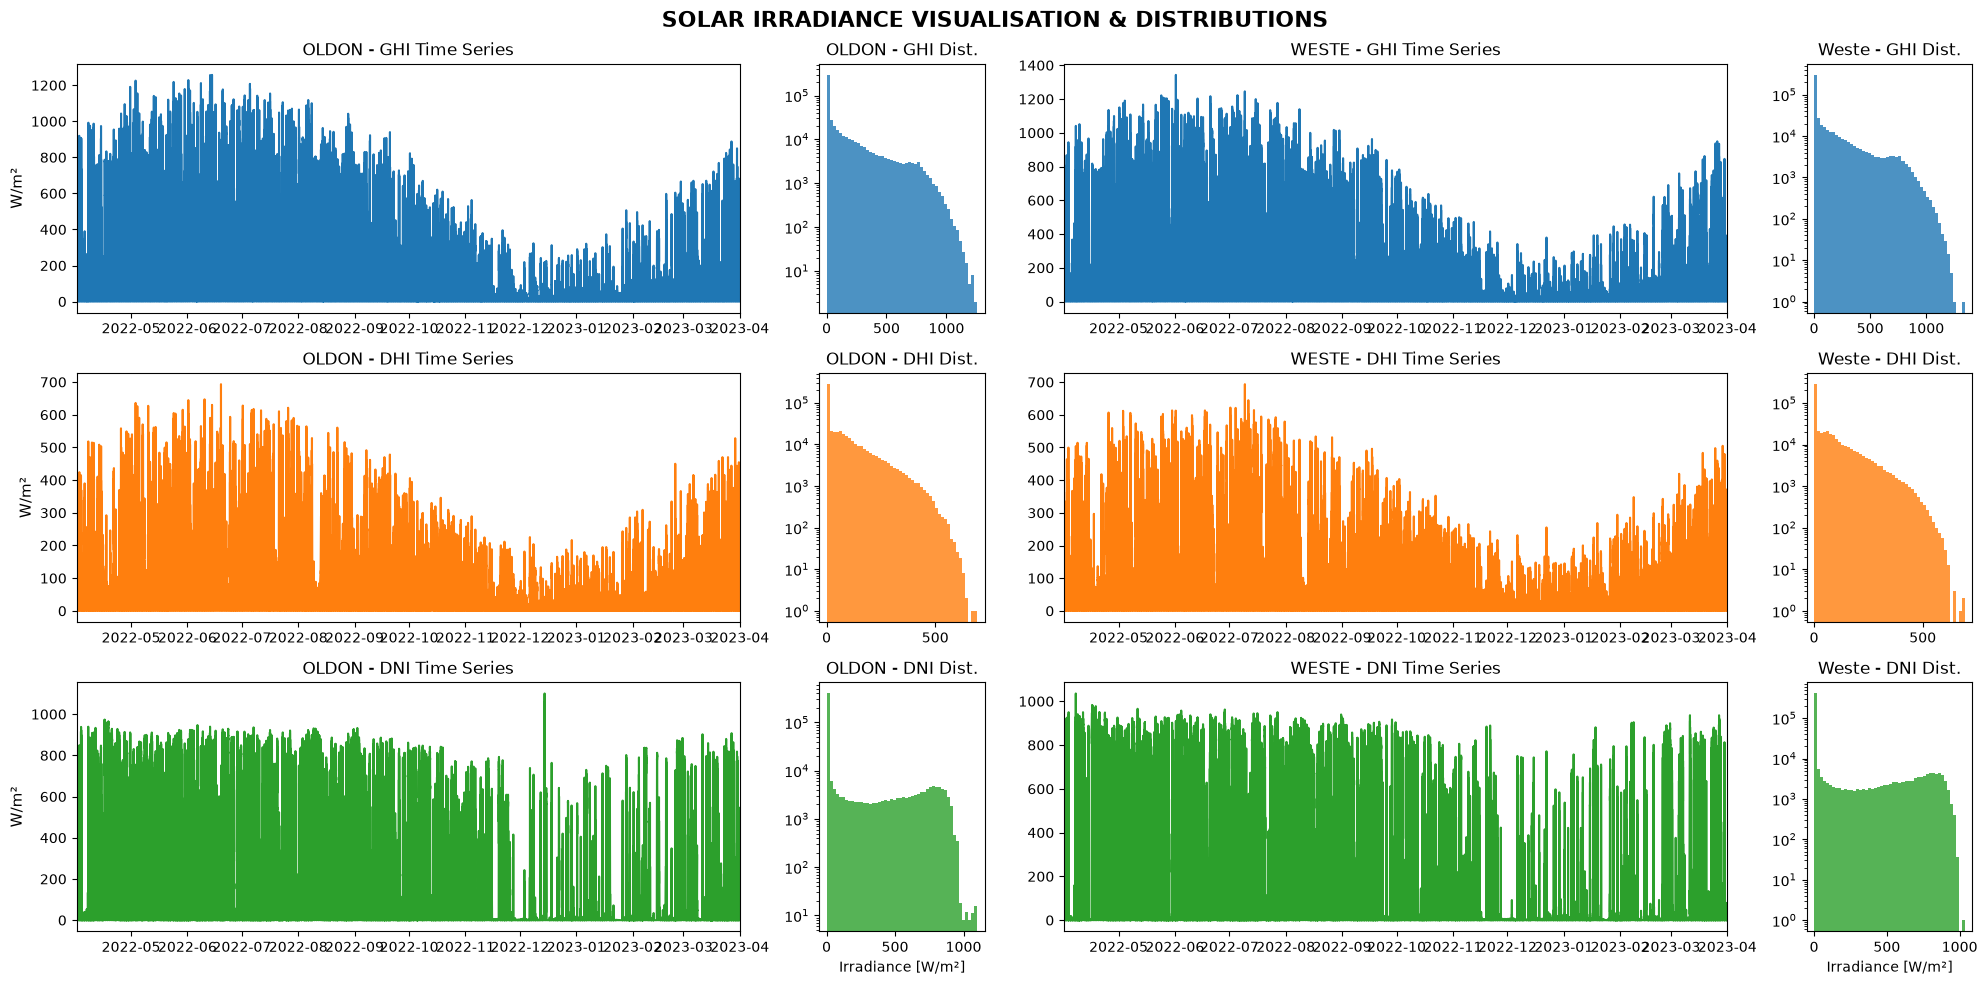

In [100]:
#SIDE BY SIDE DATA PLOTTING
#Station timeseries and  histograms

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 10), 
    sharex='none',                                #histograms and Time-Series have different X-axes
    gridspec_kw={'width_ratios': [4, 1, 4, 1]}    #width_ratios makes the time plots wide and the histograms narrow
)

for row, (o_data, e_data, label, color) in enumerate(zip(
    [ghi_oldon, dhi_oldon, dni_oldon],
    [ghi_weste, dhi_weste, dni_weste],
    ['GHI', 'DHI', 'DNI'],
    ['C0', 'C1', 'C2']       
)):
    
    # OLDON STATION
    axes[row, 0].plot(times_oldon, o_data, color=color)
    axes[row, 0].set_title(f'OLDON - {label} Time Series')
    axes[row, 0].set_ylabel('W/m²', fontsize=11)
    axes[row, 0].set_xlim(times_oldon[0], times_oldon[-1])
    
    axes[row, 1].hist(o_data, bins=50, log=True, facecolor=color, edgecolor='none', alpha=0.8)
    axes[row, 1].set_title(f'OLDON - {label} Dist.')

    # weste STATION
    axes[row, 2].plot(times_weste, e_data, color=color)
    axes[row, 2].set_title(f'WESTE - {label} Time Series')
    axes[row, 2].set_xlim(times_weste[0], times_weste[-1])
    
    axes[row, 3].hist(e_data, bins=50, log=True, facecolor=color, edgecolor='none', alpha=0.8)
    axes[row, 3].set_title(f'Weste - {label} Dist.')
    
    if row < 2:
        axes[row, 0].set_xlabel('')
        axes[row, 2].set_xlabel('')
    else:
        axes[row, 1].set_xlabel('Irradiance [W/m²]')
        axes[row, 3].set_xlabel('Irradiance [W/m²]')

fig.suptitle('SOLAR IRRADIANCE VISUALISATION & DISTRIBUTIONS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [101]:
#solar envelope
#daily sunrise and sunset times based on
#each station specific geographic coordinates and timelime

#oldon
days_oldon = pd.date_range(times_oldon[0], times_oldon[-1], freq='D')
days_oldon = days_oldon.tz_localize('Europe/Berlin')
ss_oldon = pvlib.solarposition.sun_rise_set_transit_spa(days_oldon, latitude=53.14637, longitude=8.21733)
#convert datetime values to decimal hours (0 to 24)
ss_oldon['sunrise'] = ss_oldon['sunrise'].dt.hour + ss_oldon['sunrise'].dt.minute / 60
ss_oldon['sunset'] = ss_oldon['sunset'].dt.hour + ss_oldon['sunset'].dt.minute / 60

#weste 
days_weste = pd.date_range(times_weste[0], times_weste[-1], freq='D')
days_weste = days_weste.tz_localize('Europe/Berlin')
ss_weste = pvlib.solarposition.sun_rise_set_transit_spa(days_weste, latitude=53.25335, longitude=7.92658)
ss_weste['sunrise'] = ss_weste['sunrise'].dt.hour + ss_weste['sunrise'].dt.minute / 60
ss_weste['sunset'] = ss_weste['sunset'].dt.hour + ss_weste['sunset'].dt.minute / 60

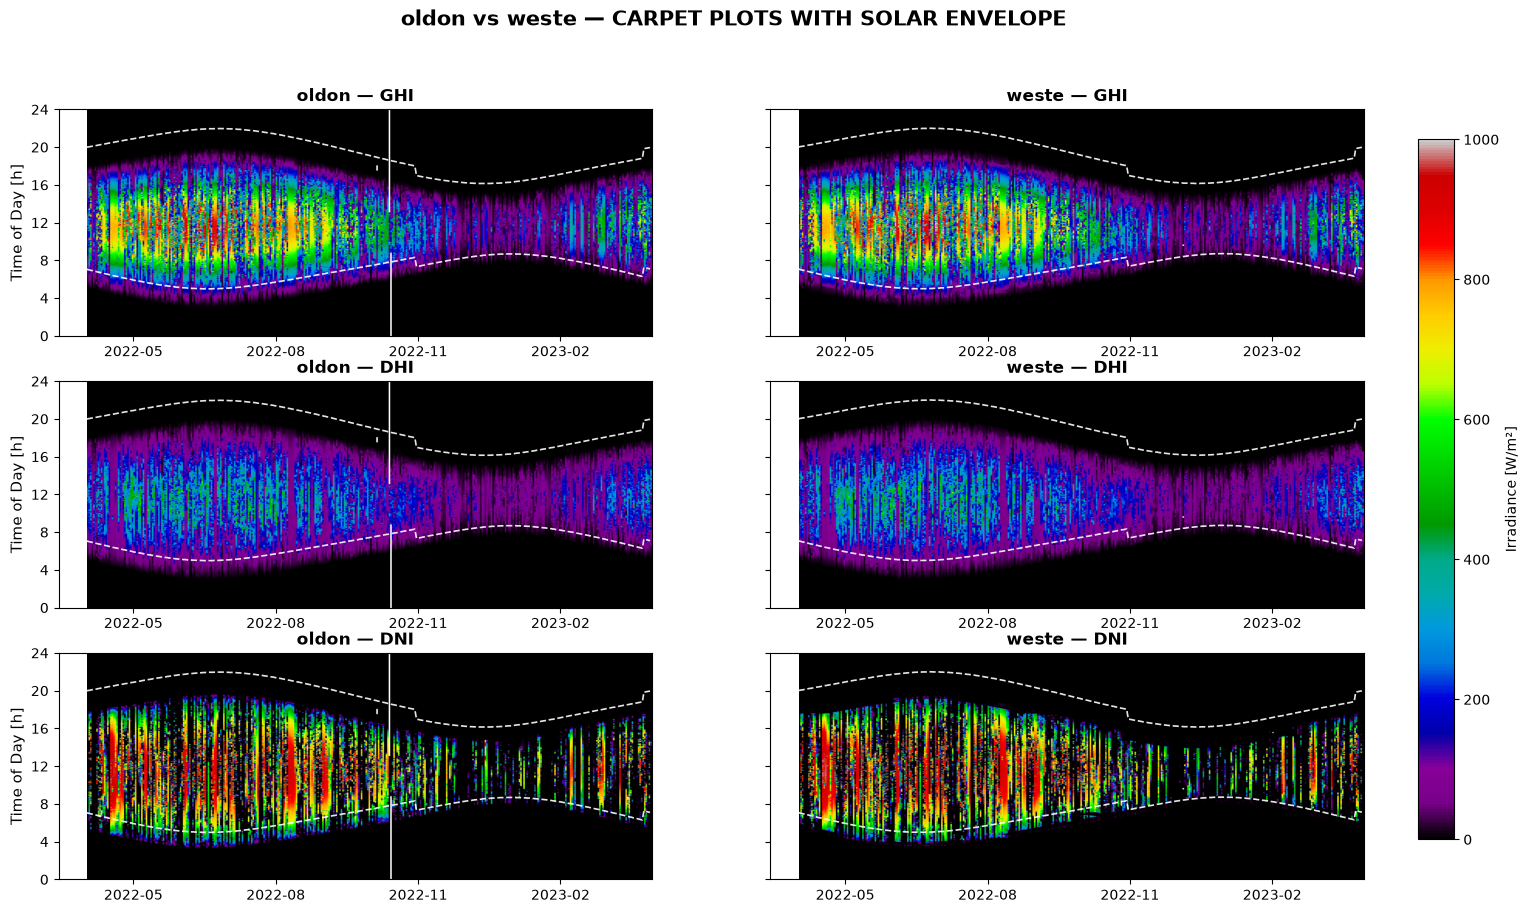

In [102]:

fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=False, sharey=True)

components = [('GHI', ghi_oldon, ghi_weste), ('DHI', dhi_oldon, dhi_weste), ('DNI', dni_oldon, dni_weste)]

for row, (name, o_data, e_data) in enumerate(components):
    for col, (data, times, station, ss_data) in enumerate([
        (o_data, times_oldon, 'oldon', ss_oldon),
        (e_data, times_weste, 'weste', ss_weste)
    ]):
        
        #shape the 1D array into a 2D Day-by-Minute Matrix
        n_days = len(data) // 1440
        matrix = data[:n_days * 1440].reshape(n_days, 1440)

        #map coordinates to continuous dates (X) and 0-24 hours (Y)
        start_date = times[0].normalize()  
        end_date = times[-1].normalize()
        xlims = mdates.date2num([start_date, end_date])
        station_extent = [xlims[0], xlims[1], 0, 24]

        im = axes[row, col].imshow(matrix.T, aspect='auto', origin='lower',
            cmap='nipy_spectral',
            vmin=0,
            vmax=1000,
            extent=station_extent
        )

        axes[row, col].set_title(f'{station} — {name}', fontsize=12, fontweight='bold')

        #overlay the station's specific sunrise and sunset curves
        #convert the index to matplotlib numbers so lines match the x-axis calendar dates
        ss_dates = mdates.date2num(ss_data.index)
        axes[row, col].plot(ss_dates, ss_data['sunrise'], 'w--', lw=1.2, alpha=0.9)
        axes[row, col].plot(ss_dates, ss_data['sunset'], 'w--', lw=1.2, alpha=0.9)

        #y-axis layout
        axes[row, col].set_yticks(np.arange(0, 25, 4))
        if col == 0:
            axes[row, col].set_ylabel('Time of Day [h]', fontsize=11)

        #x-axis layout
        axes[row, col].xaxis_date()
        axes[row, col].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        axes[row, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Irradiance [W/m²]')

fig.suptitle('oldon vs weste — CARPET PLOTS WITH SOLAR ENVELOPE', fontsize=15, fontweight='bold')
plt.show()

**Checking for missing data**

It is important to first ensure that the time series has a consistent frequency, e.g. that that there are no missing timestamps. This can be achieved using the asfreq pandas function, which converts the time-series to a consistent frequency (e.g., 1 min., 15 min., or 1 hour), by adding missing rows.

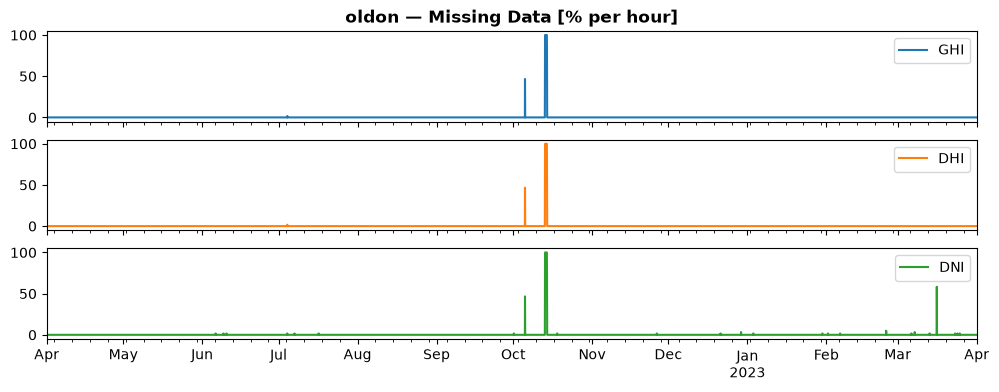

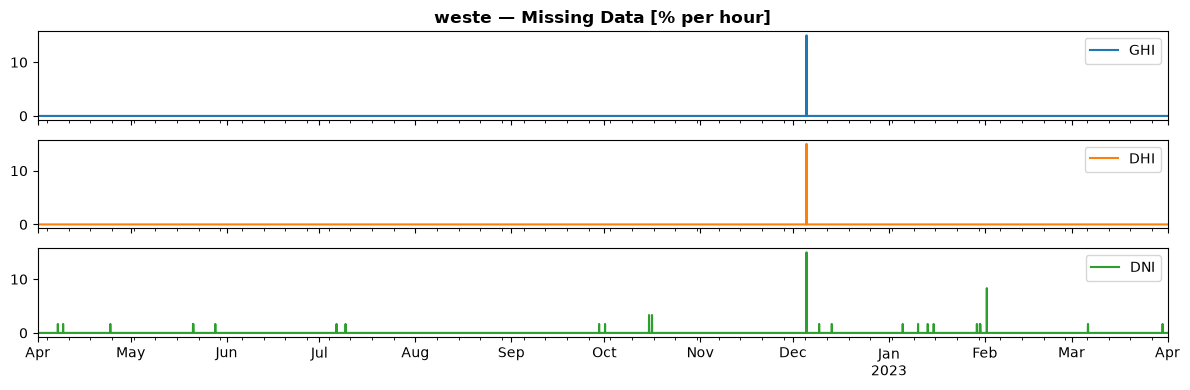

In [103]:
#PLOTTING MISSING DATA HOURLY TIMELINES

#ensure the timeline is perferctly continous
#if a min is missing bc the system turned off, this adds it back as a NaN
#oldon
df_oldon = pd.DataFrame({'GHI': ghi_oldon, 'DHI': dhi_oldon, 'DNI': dni_oldon}, index=times_oldon).asfreq('1min')

#downsample the resolution 60s time series into hourly intervals
#compress 1M min of data so it is readable on a graph
#this counts the missing min per hour and converts them into a 0-100% scale.
axes_oldon = df_oldon.isna().astype(float).resample('1h').sum().divide(60/100).plot(subplots=True, figsize=(12, 4), sharex=True)
axes_oldon[0].set_title('oldon — Missing Data [% per hour]', fontsize=12, fontweight='bold')


#weste STATION
df_weste = pd.DataFrame({'GHI': ghi_weste, 'DHI': dhi_weste, 'DNI': dni_weste}, index=times_weste).asfreq('1min')

#percentage of missing data per hour
axes_weste = df_weste.isna().astype(float).resample('1h').sum().divide(60/100).plot(subplots=True, figsize=(12, 4), sharex=True)
axes_weste[0].set_title('weste — Missing Data [% per hour]', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

The structural difference in missing data profiles between the two stations is a direct result of their processing baselines.

In [104]:
#computing solar position paramaters
#for all stored timestamps
#solar position is required to determine the sun's zenith and azimuth
#angles, which are later used for irradiance and PV performance analysis

#oldon site configuration
lat_oldon, lon_oldon, alt_oldon = 53.14637, 8.21733, 20

solpos_oldon = pvlib.solarposition.get_solarposition(
    times_oldon,
    lat_oldon,
    lon_oldon,
    altitude=alt_oldon
)

#weste site configuration

lat_weste, lon_weste, alt_weste = 53.25335, 7.92658, 10
solpos_weste = pvlib.solarposition.get_solarposition(
    times_weste,
    lat_weste,
    lon_weste,
    altitude=alt_weste
)

In [105]:
#extraction of apparent zenith angle
zenith_oldon = solpos_oldon['apparent_zenith']
zenith_weste = solpos_weste['apparent_zenith']

## **QC TESTS** ##

**LIMIT CHECK**

- Physical possible limits

Physically Possible Limits (PPL) check the maximum and minimum limits that can be reached by irradiance, where the upper limits depend on the solar zenith angle. The minimal value of solar irradiance is 0 W/m², however, because of the radiative cooling at night, which induces thermal offsets in the radiometers, the lower limit is set to -4 W/m².

- Extremely rare limits

The limits of the “Extremely Rare Limits”(ERL) procedure are stricter than the Physically Possible Limits. ERL differs from the PPL test in that valid measurements rarely reach the ERL limits, and even if they do, often only for very short periods of a few seconds to one or two minutes. Measurements exceeding these limits are not necessarily erroneous, but their plausibility should be checked more carefully


In [106]:
#building dataframes with solar geometry

def build_df(ghi, dhi, dni, solpos, times):
    dni_extra = pvlib.irradiance.get_extra_radiation(times).values
    zenith    = solpos['apparent_zenith'].values
    elevation = solpos['elevation'].values
    cos_sza   = np.cos(np.radians(zenith))
    mu0       = np.clip(cos_sza, 0, None)

    return pd.DataFrame({'GHI': ghi, 'DHI': dhi, 'DNI': dni, 'zenith': zenith, 'elevation': elevation, 
                         'extra_radiation': dni_extra, 'mu0': mu0}, index=times)

#computing BSRN limits and flags

def build_limits_and_flags(data):
    limits = pd.DataFrame(index=data.index, data={
        'zenith'   : data['zenith'],
        'elevation': data['elevation']
    })

    limits['ppl_upper_GHI'] = 1.5  * data['extra_radiation'] * data['mu0']**1.2 + 100
    limits['ppl_upper_DHI'] = 0.95 * data['extra_radiation'] * data['mu0']**1.2 + 50
    limits['ppl_upper_DNI'] = 1.0  * data['extra_radiation']

    limits['erl_upper_GHI'] = 1.2  * data['extra_radiation'] * data['mu0']**1.2 + 50
    limits['erl_upper_DHI'] = 0.75 * data['extra_radiation'] * data['mu0']**1.2 + 30
    limits['erl_upper_DNI'] = 0.95 * data['extra_radiation'] * data['mu0']**0.2 + 10

    flags  = pd.DataFrame(index=data.index)
    daytime   = data['elevation'] > 0        #BSRN rules only apply when sun is above horizon

    for c in ['GHI', 'DHI', 'DNI']:          #components
        exceeds_erl       = (data[c] > limits[f'erl_upper_{c}']) & daytime
        exceeds_ppl       = (data[c] > limits[f'ppl_upper_{c}']) & daytime
        drops_below_floor = (data[c] < -5) & daytime

        flags[f'{c}_exceeds_ERL'] = exceeds_erl
        flags[f'{c}_exceeds_PPL'] = exceeds_ppl | drops_below_floor

    return limits, flags


In [107]:
df_oldon = build_df(ghi_oldon, dhi_oldon, dni_oldon, solpos_oldon, times_oldon)
df_weste = build_df(ghi_weste, dhi_weste, dni_weste, solpos_weste, times_weste)

limits_oldon, flags_oldon = build_limits_and_flags(df_oldon)
limits_weste, flags_weste = build_limits_and_flags(df_weste)

print('-- oldon --')
print('PPL flags:', flags_oldon[[c for c in flags_oldon if 'PPL' in c]].any(axis=1).sum())
print('ERL flags:', flags_oldon[[c for c in flags_oldon if 'ERL' in c]].any(axis=1).sum())
print('\n-- weste --')
print('PPL flags:', flags_weste[[c for c in flags_weste if 'PPL' in c]].any(axis=1).sum())
print('ERL flags:', flags_weste[[c for c in flags_weste if 'ERL' in c]].any(axis=1).sum())

-- oldon --
PPL flags: 5
ERL flags: 163

-- weste --
PPL flags: 2
ERL flags: 150


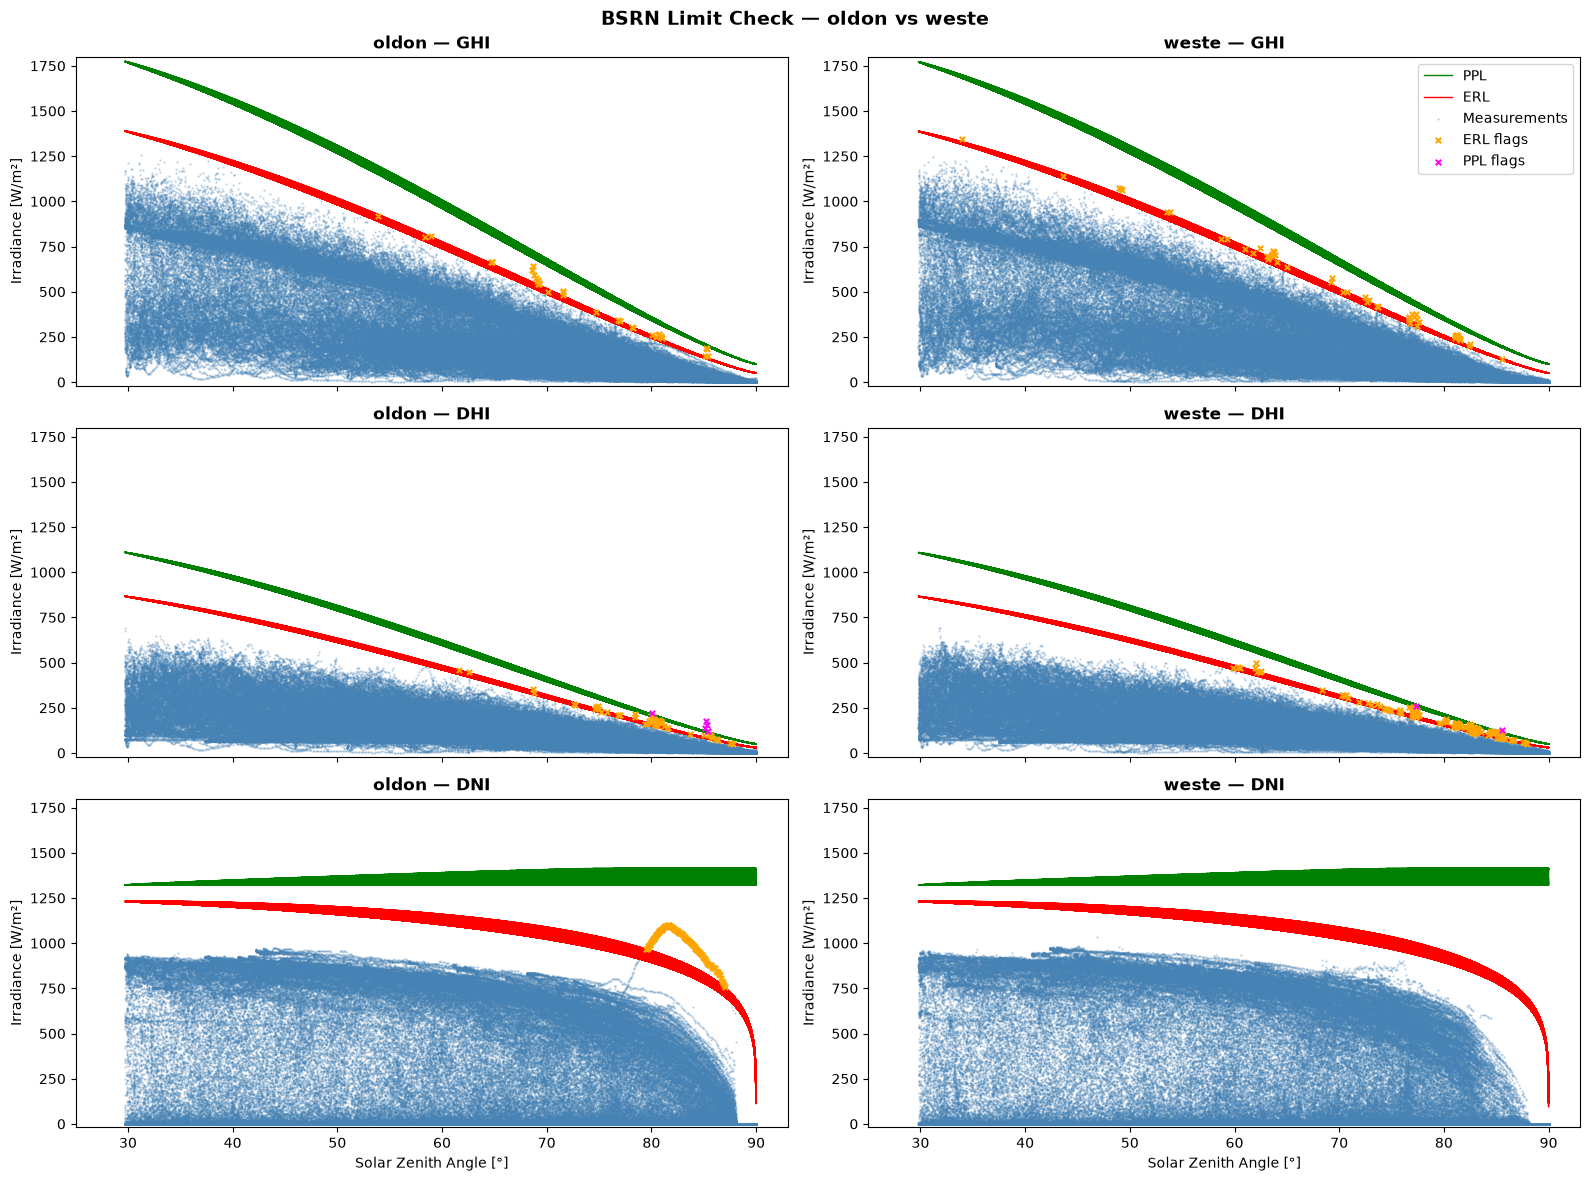

In [108]:
#plotting

def plot_limits(ax, data, limits, flags, component, station):
    mask   = limits['zenith'].values < 90
    zen    = limits['zenith'].values
    val    = data[component].values
    is_erl = flags[f'{component}_exceeds_ERL'].values
    is_ppl = flags[f'{component}_exceeds_PPL'].values

    ax.plot(zen[mask], limits[f'ppl_upper_{component}'].values[mask], c='green', lw=1.0, label='PPL')
    ax.plot(zen[mask], limits[f'erl_upper_{component}'].values[mask], c='red', lw=1.0, label='ERL')
    ax.scatter(zen[mask & ~is_erl & ~is_ppl], val[mask & ~is_erl & ~is_ppl], s=0.4, alpha=0.3, color='steelblue', label='Measurements')
    ax.scatter(zen[mask & is_erl & ~is_ppl], val[mask & is_erl & ~is_ppl], s=15, c='orange', marker='x', zorder=4, label='ERL flags')
    ax.scatter(zen[mask & is_ppl], val[mask & is_ppl], s=15, c='magenta', marker='x', zorder=5, label='PPL flags')

    ax.set_title(f'{station} — {component}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Irradiance [W/m²]')
    ax.set_xlim(25, 93)
    ax.set_ylim(-20, 1800)

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

for i, c in enumerate(['GHI', 'DHI', 'DNI']):
    plot_limits(axes[i, 0], df_oldon, limits_oldon, flags_oldon, c, 'oldon')
    plot_limits(axes[i, 1], df_weste, limits_weste, flags_weste, c, 'weste')

axes[0, 1].legend(loc='upper right')
axes[2, 0].set_xlabel('Solar Zenith Angle [°]')
axes[2, 1].set_xlabel('Solar Zenith Angle [°]')
fig.suptitle('BSRN Limit Check — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

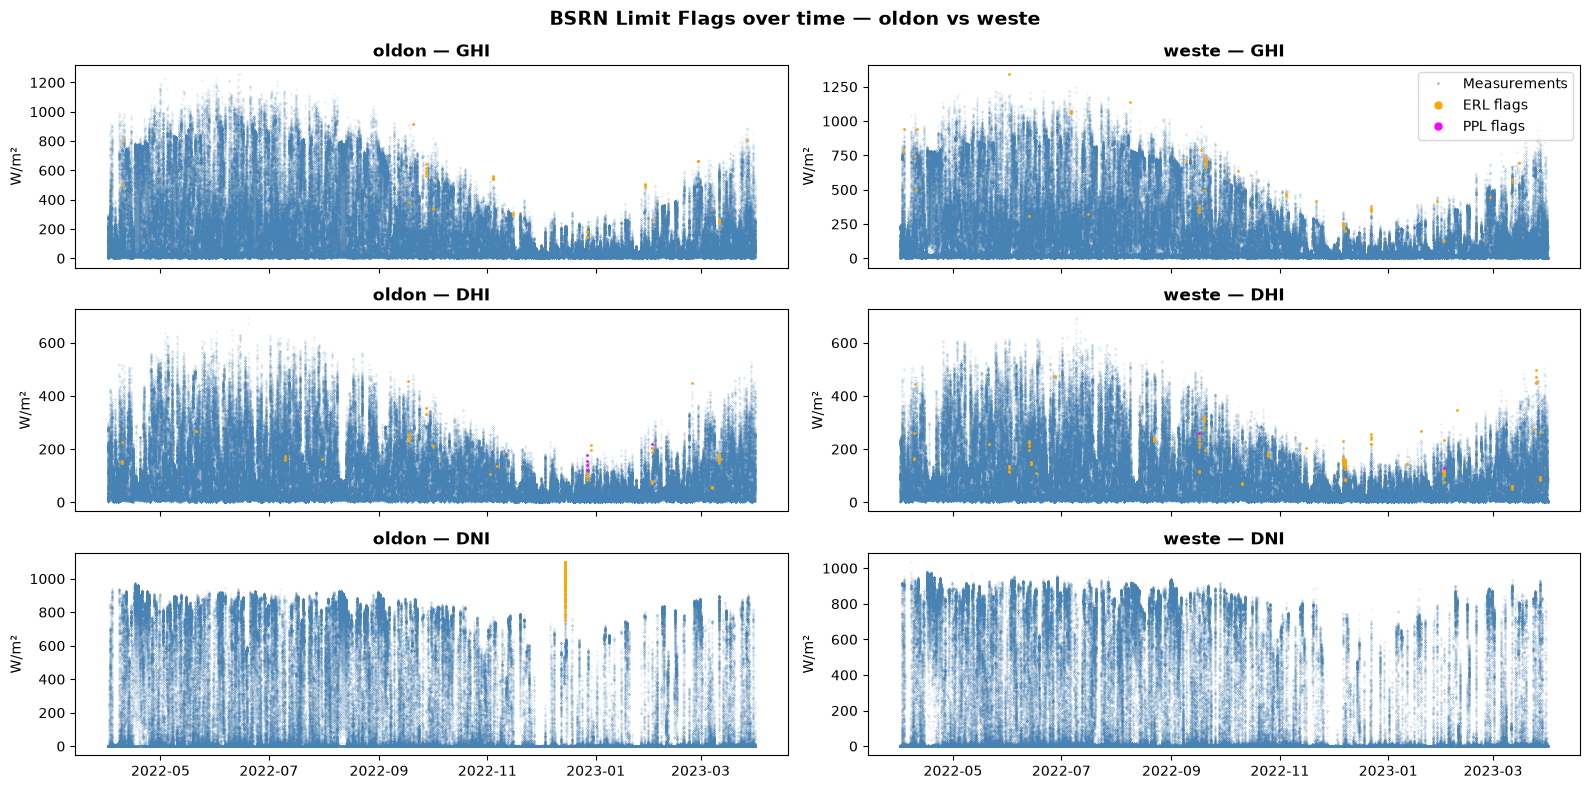

In [109]:
fig, axes = plt.subplots(3, 2, figsize=(16, 8), sharex=True)

for i, c in enumerate(['GHI', 'DHI', 'DNI']):
    for col, (data, limits, flags, times, station) in enumerate([
        (df_oldon, limits_oldon, flags_oldon, times_oldon, 'oldon'),
        (df_weste, limits_weste, flags_weste, times_weste, 'weste')
    ]):
        ax     = axes[i, col]
        val    = data[c].values
        is_erl = flags[f'{c}_exceeds_ERL'].values
        is_ppl = flags[f'{c}_exceeds_PPL'].values
        daytime = limits['elevation'].values > 0

        #measurements
        ax.plot(times[daytime & ~is_erl & ~is_ppl], val[daytime & ~is_erl & ~is_ppl], '.', ms=0.3, alpha=0.6, color='steelblue', label='Measurements')
        #flags
        ax.plot(times[is_erl & ~is_ppl], val[is_erl & ~is_ppl], '.', ms=2, color='orange', label='ERL flags')
        ax.plot(times[is_ppl], val[is_ppl], '.', ms=2, color='magenta', label='PPL flags')
        ax.set_title(f'{station} — {c}', fontsize=12, fontweight='bold')
        ax.set_ylabel('W/m²')

axes[0, 1].legend(loc='upper right', markerscale=5)
fig.suptitle('BSRN Limit Flags over time — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tests were run for oldon and weste sattions using Baseline Surface Radiation Network standards toc catch sensor anomalies:

- oldon DNI drops: flagged midday DNI data points dropping all the way to zero or below −5 W/m² (shown in magenta). Since the sun was high in the sky, these are not real atmospheric events. They point to temporary instrument issues, such as a solar tracker briefly losing alignment or a momentary signal glitch.

- weste Station (DHI Spikes): flagged a clear cluster of high diffuse light spikes at low zenith angles (30&deg;C – 35&deg;C, shown in orange). These indicate either severe cloud-edge reflections or a misalignment of the tracking shade ball that is supposed to block the direct sun.

**COMPARISON TESTS**

**Closure test**

BSRN three-component ratio: the ratio GHI/(DHI + DNIxcos(SZA)) was computed and compared against BSRN tolerance bands (8% for SZA < 75&deg;C and 15% for SZA > 75&deg;C). 

In [110]:
def compute_closure(ghi, dhi, dni, solpos):
    sza     = solpos['apparent_zenith'].values
    cos_sza = np.cos(np.radians(sza))
    ghi_rec   = dhi + dni * cos_sza

    #ratio GHI / (DHI + DNI*cos(SZA))
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(ghi_rec > 0, ghi / ghi_rec, np.nan)

    valid_domain = (sza < 93) & (ghi_rec > 50)    #valid domain

    #two-tier BSRN thresholds
    deviation = np.abs(ratio - 1.0)
    flag = (((sza <= 75) & (deviation > 0.08)) | ((sza >  75) & (deviation > 0.15))) & valid_domain

    flag[np.isnan(ghi) | np.isnan(dhi) | np.isnan(dni)] = False      #mask NaNs

    return ratio, flag, sza, valid_domain

#run for both stations
ratio_olw, flags_olw, sza_olw, domain_olw = compute_closure(ghi_oldon, dhi_oldon, dni_oldon, solpos_oldon)
ratio_esr, flags_esr, sza_esr, domain_esr = compute_closure(ghi_weste, dhi_weste, dni_weste, solpos_weste)

print("oldon closure flags:", flags_olw.sum())
print("weste closure flags:", flags_esr.sum())

oldon closure flags: 0
weste closure flags: 0


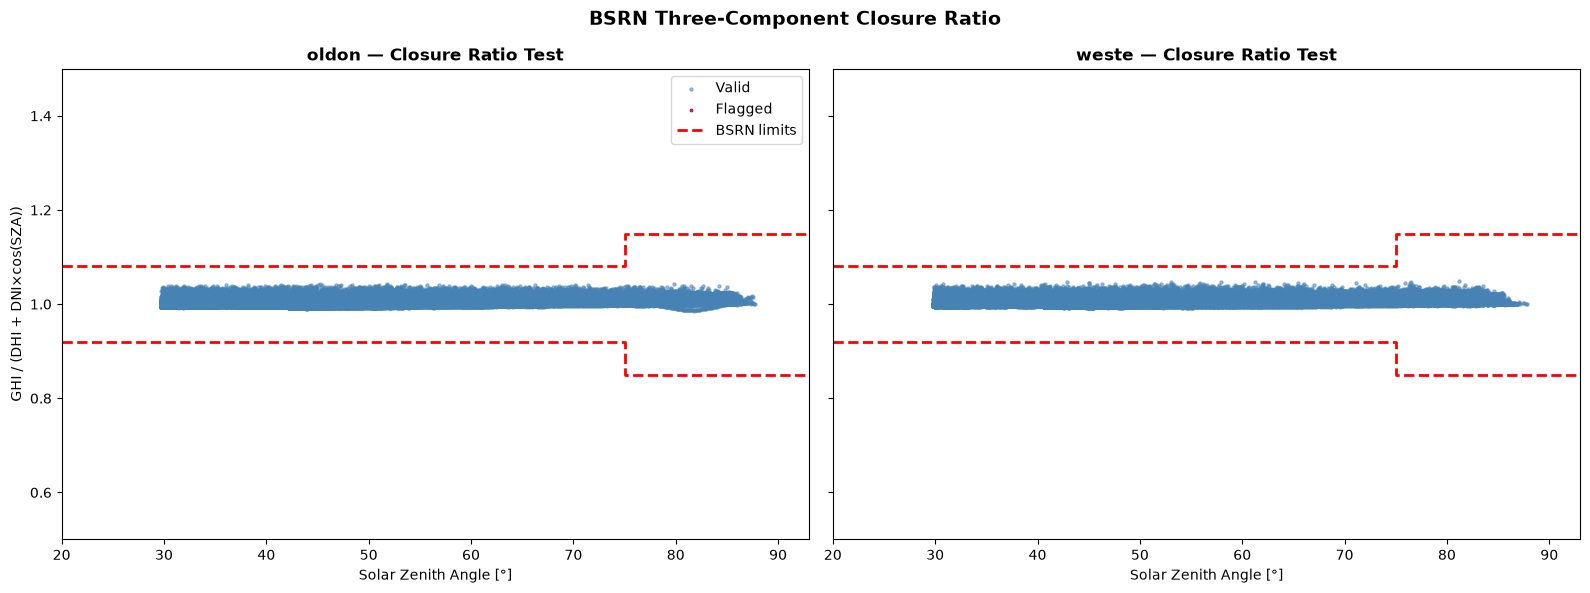

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)    #plotting

for ax, (name, sza, ratio, flags, domain) in zip(axes, [
    ('oldon', sza_olw, ratio_olw, flags_olw, domain_olw),
    ('weste', sza_esr, ratio_esr, flags_esr, domain_esr)
]):
    clean = domain & ~np.isnan(ratio)

    ax.scatter(sza[clean & ~flags], ratio[clean & ~flags], s=5, alpha=0.5, color='steelblue', label='Valid')
    ax.scatter(sza[clean & flags], ratio[clean & flags], s=12, marker='.', color='crimson', label='Flagged')

    #BSRN step limits (found in the paper: doi: 10.14710/ijred.2021.34806)
    
    ax.plot([20, 75, 75, 93], [1.08, 1.08, 1.15, 1.15], color='red', lw=2, linestyle='--', label='BSRN limits')
    ax.plot([20, 75, 75, 93], [0.92, 0.92, 0.85, 0.85], color='red', lw=2, linestyle='--')

    ax.set_title(f'{name} — Closure Ratio Test', fontsize=12, fontweight='bold')
    ax.set_xlabel('Solar Zenith Angle [°]')
    ax.set_xlim(20, 93)
    ax.set_ylim(0.5, 1.5)

axes[0].set_ylabel('GHI / (DHI + DNI×cos(SZA))')
axes[0].legend(loc='upper right')
fig.suptitle('BSRN Three-Component Closure Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

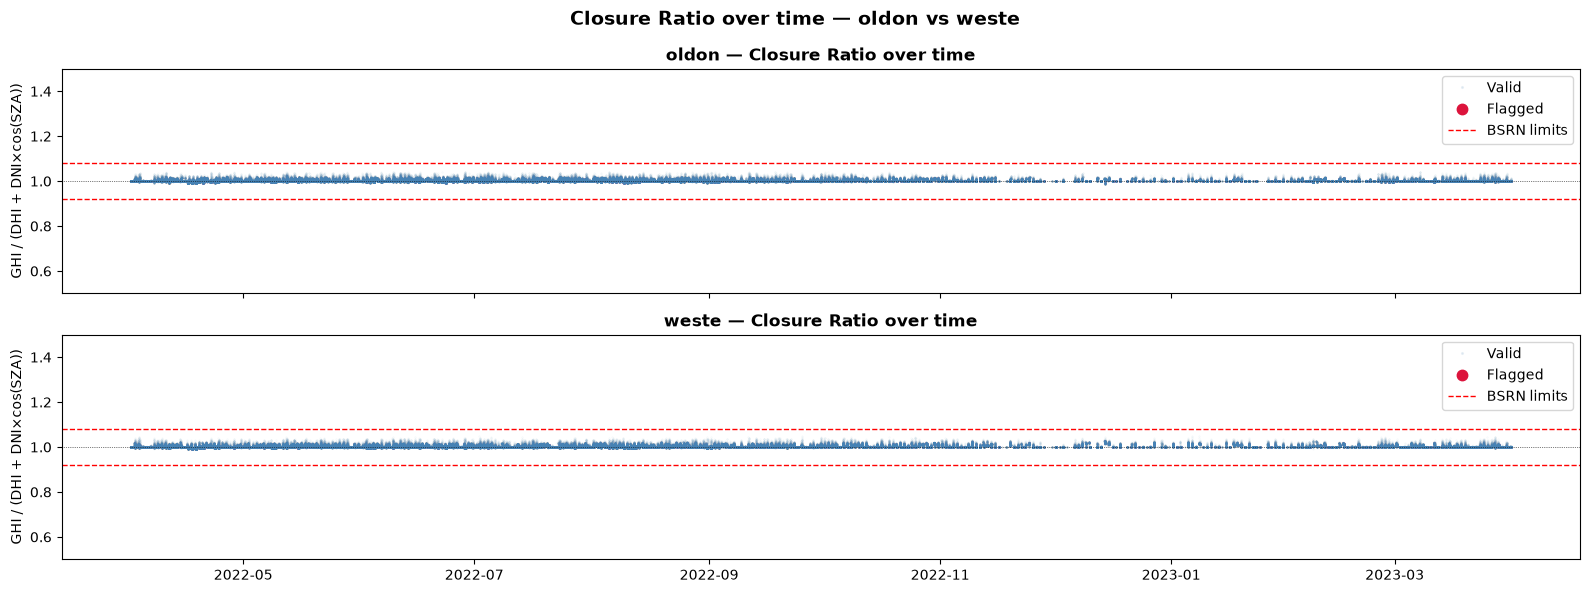

In [112]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

for ax, (name, ratio, flags, domain, times) in zip(axes, [
    ('oldon', ratio_olw, flags_olw, domain_olw, times_oldon),
    ('weste', ratio_esr, flags_esr, domain_esr, times_weste)
]):
    clean = domain & ~np.isnan(ratio)

    ax.plot(times[clean & ~flags], ratio[clean & ~flags], '.', ms=0.5, alpha=0.1, color='steelblue', label='Valid')
    ax.plot(times[clean & flags], ratio[clean & flags], '.', ms=3, color='crimson', label='Flagged')

    ax.axhline(1.08, color='red', lw=1, linestyle='--', label='BSRN limits')
    ax.axhline(0.92, color='red', lw=1, linestyle='--')
    ax.axhline(1.0,  color='black', lw=0.5, linestyle=':')

    ax.set_title(f'{name} — Closure Ratio over time', fontsize=12, fontweight='bold')
    ax.set_ylabel('GHI / (DHI + DNI×cos(SZA))')
    ax.set_ylim(0.5, 1.5)
    ax.legend(loc='upper right', markerscale=5)

#axes[1].set_xlabel('Date')
fig.suptitle('Closure Ratio over time — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- oldon showed a tight ratio distribution around 1.0 for SZA < 75&deg;C, with flags ilimited to cloud enhancement events. 
- weste showed a systematically wider distribution across all zenith angles, with massive red flad counts especially at SZA > 75&deg;C. This may be attributed to the independent temperature and zenithal angle corrections applied to each component breaking the fundamental closure relationship.

**Diffuse Ratio**

Where GHI and DHI measurements are available, a comparison of these two measures can be checked for consistency by applying, for GHI>50 W/m.  

These tests are non-
definitive, i.e., the particular component that causes the test to fail is unknown after the test.

In [113]:
def test_two_component(ghi, dhi, solpos):
    sza = solpos['apparent_zenith'].values
    valid_range = (ghi > 50) & (sza < 93)
    flag = (((sza <= 75) & (dhi > 1.05 * ghi)) | 
            ((sza > 75) & (dhi > 1.10 * ghi))) & valid_range
    
    flag[np.isnan(ghi) | np.isnan(dhi)] = False
    return flag, sza

flag_2c_oldon, sza_oldon = test_two_component(ghi_oldon, dhi_oldon, solpos_oldon)
flag_2c_weste, sza_weste = test_two_component(ghi_weste, dhi_weste, solpos_weste)

print('oldon two-component flags:', flag_2c_oldon.sum())
print('weste two-component flags:', flag_2c_weste.sum())

oldon two-component flags: 0
weste two-component flags: 0


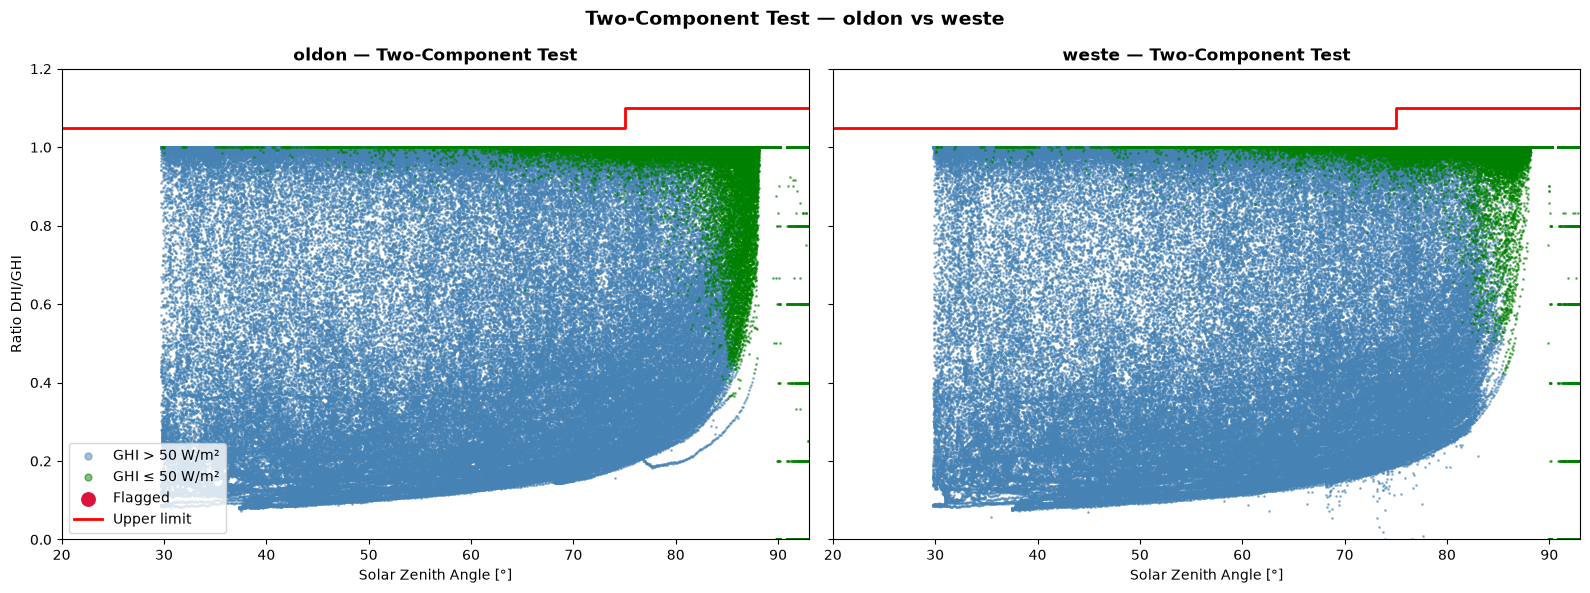

In [114]:
#plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (name, ghi, dhi, sza, flag) in zip(axes, [
    ('oldon', ghi_oldon, dhi_oldon, sza_oldon, flag_2c_oldon),
    ('weste', ghi_weste, dhi_weste, sza_weste, flag_2c_weste)
]):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(ghi > 0, dhi / ghi, np.nan)

    not_nan = ~np.isnan(ratio)
    sza_ok = sza < 93

    ax.scatter(sza[(ghi > 50) & sza_ok & not_nan & ~flag], ratio[(ghi > 50)  & sza_ok & not_nan & ~flag], s=1, alpha=0.5, color='steelblue', label='GHI > 50 W/m²')
    ax.scatter(sza[(ghi <= 50) & sza_ok & not_nan], ratio[(ghi <= 50) & sza_ok & not_nan], s=1, alpha=0.5, color='green', label='GHI ≤ 50 W/m²')
    ax.scatter(sza[(ghi > 50) & sza_ok & not_nan & flag], ratio[(ghi > 50)  & sza_ok & not_nan &  flag], s=15, color='crimson', marker='.', zorder=5, label='Flagged')
    
    ax.plot([0, 75, 75, 93], [1.05, 1.05, 1.10, 1.10], color='red', lw=2, label='Upper limit')
    ax.set_title(f'{name} — Two-Component Test', fontsize=12, fontweight='bold')
    ax.set_xlabel('Solar Zenith Angle [°]')
    ax.set_xlim(20, 93)
    ax.set_ylim(0, 1.2)

axes[0].set_ylabel('Ratio DHI/GHI')
axes[0].legend(loc='lower left', markerscale=5)
fig.suptitle('Two-Component Test — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**as a function of time**

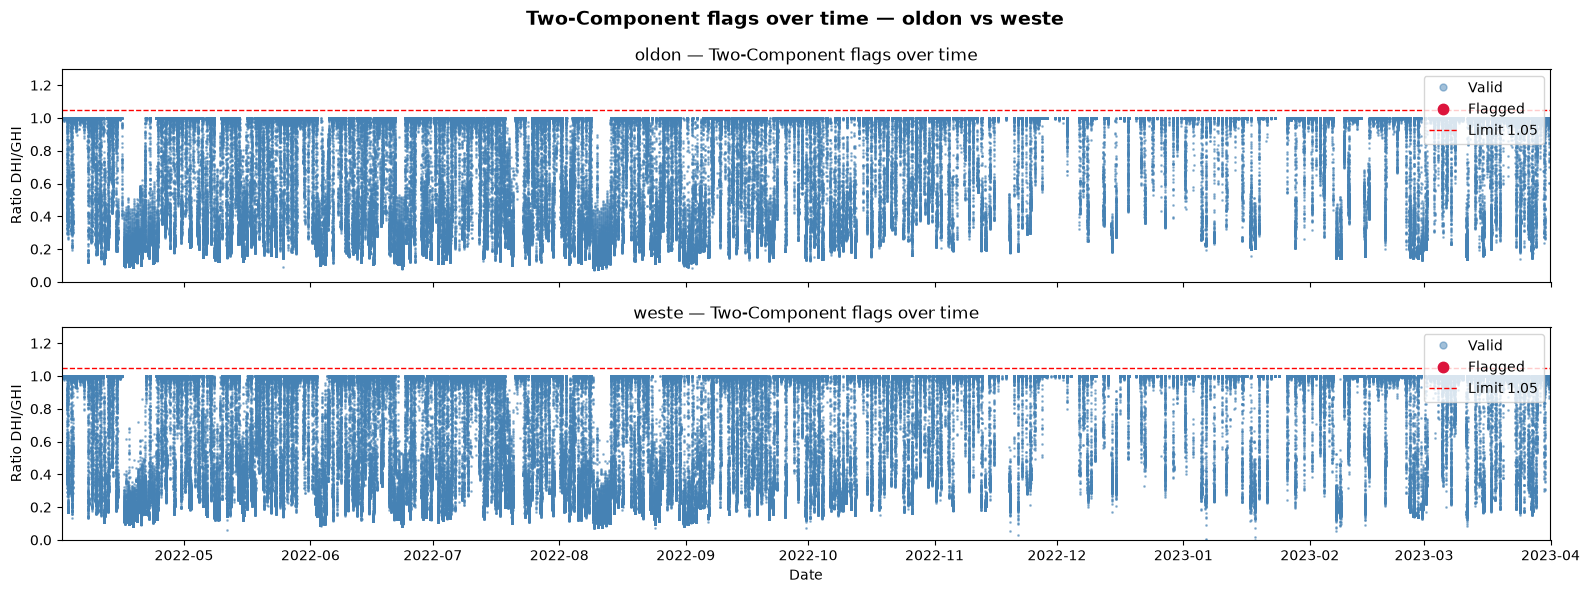

In [115]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

for ax, (name, ghi, dhi, sza, flag, times) in zip(axes, [
    ('oldon', ghi_oldon, dhi_oldon, sza_oldon, flag_2c_oldon, times_oldon),
    ('weste', ghi_weste, dhi_weste, sza_weste, flag_2c_weste, times_weste)
]):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(ghi > 0, dhi / ghi, np.nan)

    valid = (ghi > 50) & (sza < 93) & ~np.isnan(ratio)

    ax.plot(times[valid & ~flag], ratio[valid & ~flag],'.', ms=2, alpha=0.5, color='steelblue', label='Valid')
    ax.plot(times[valid & flag], ratio[valid & flag],'.', ms=3, color='crimson', label='Flagged')

    ax.axhline(1.05, color='red', lw=1, linestyle='--', label='Limit 1.05')

    ax.set_title(f'{name} — Two-Component flags over time')
    ax.set_ylabel('Ratio DHI/GHI')
    ax.set_ylim(0, 1.3)
    ax.legend(loc='upper right', markerscale=5)

axes[1].set_xlabel('Date')
axes[1].set_xlim(times[0], times[-1])
fig.suptitle('Two-Component flags over time — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**SHADOW ANALYSIS**

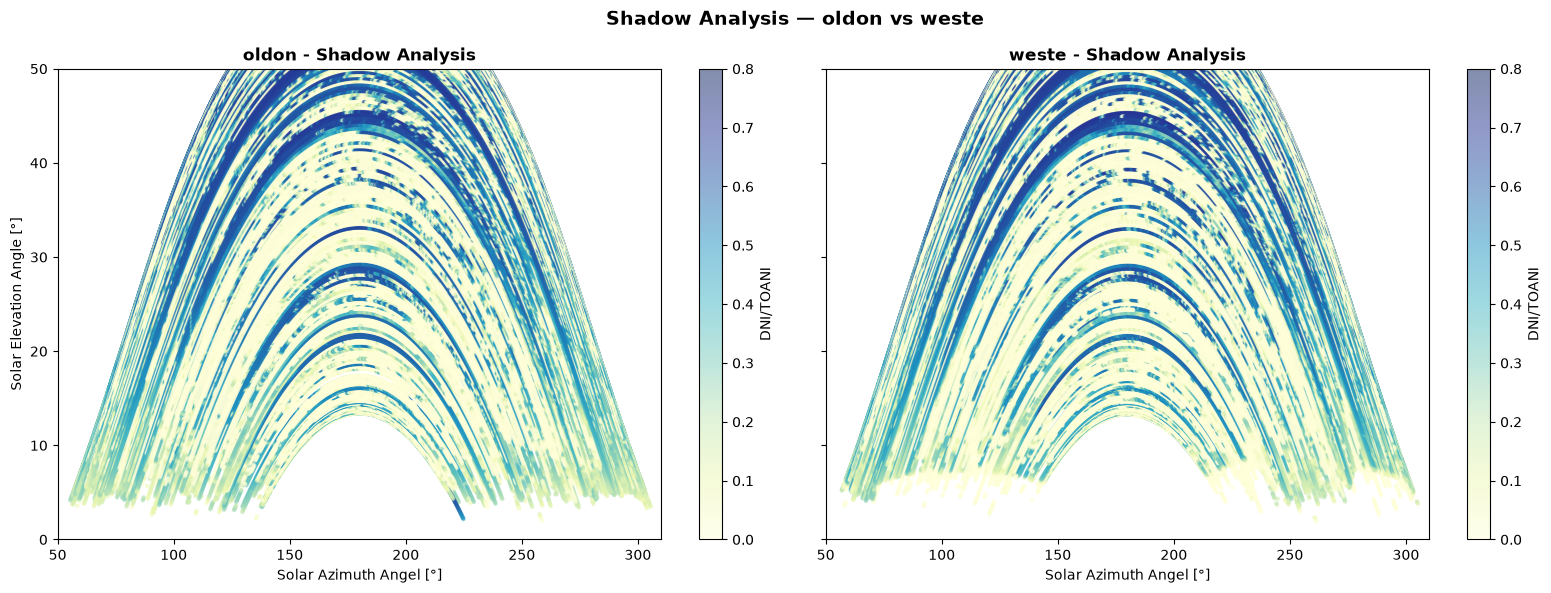

In [116]:
def plot_shadow_analysis(ghi, dni, solpos, times, station):
    dni_extra = pvlib.irradiance.get_extra_radiation(times).values
    azimuth = solpos['azimuth'].values
    elevation = solpos['elevation'].values

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(dni_extra > 0, dni / dni_extra, np.nan)

        #only daytime with sufficient irradiance
        mask = (elevation > 0) & (ghi > 50) & ~np.isnan(ratio)
        return azimuth[mask], elevation[mask], ratio[mask], station
    
az_oldon, el_oldon, ratio_oldon_sh, _ = plot_shadow_analysis(ghi_oldon, dni_oldon, solpos_oldon, times_oldon, 'oldon')
az_weste, el_weste, ratio_weste_sh, _ = plot_shadow_analysis(ghi_weste, dni_weste, solpos_weste, times_weste, 'weste')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, (az, el, ratio, station) in zip(axes, [
    (az_oldon, el_oldon, ratio_oldon_sh, 'oldon'),
(az_weste, el_weste, ratio_weste_sh, 'weste')
]):
    sc= ax.scatter(az, el, c=ratio, cmap='YlGnBu', s=5, alpha=0.5, vmin=0, vmax=0.8)
    plt.colorbar(sc, ax=ax, label='DNI/TOANI')
    ax.set_xlabel('Solar Azimuth Angel [°]')
    ax.set_title(f'{station} - Shadow Analysis', fontsize=12, fontweight='bold')
    ax.set_xlim(50, 310)
    ax.set_ylim(0, 50)

axes[0].set_ylabel('Solar Elevation Angle [°]')
fig.suptitle('Shadow Analysis — oldon vs weste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Shadow analysis was performed as part of the visual inspection to identify potential permanent obstructions at each station. No systematic dark patches were observed at specific azimuth/elevation positions in either oldon or weste, confirming that neither station is affected by permanent shadowing from nearby obstacles

Clear sky conditions.

DO  - 10.1109/ISGT-Asia.2018.8467892

oldon — cloud enhancement: 6758 (7.73%) | erroneous: 2905 (3.32%)
weste — cloud enhancement: 6977 (7.96%) | erroneous: 2777 (3.17%)


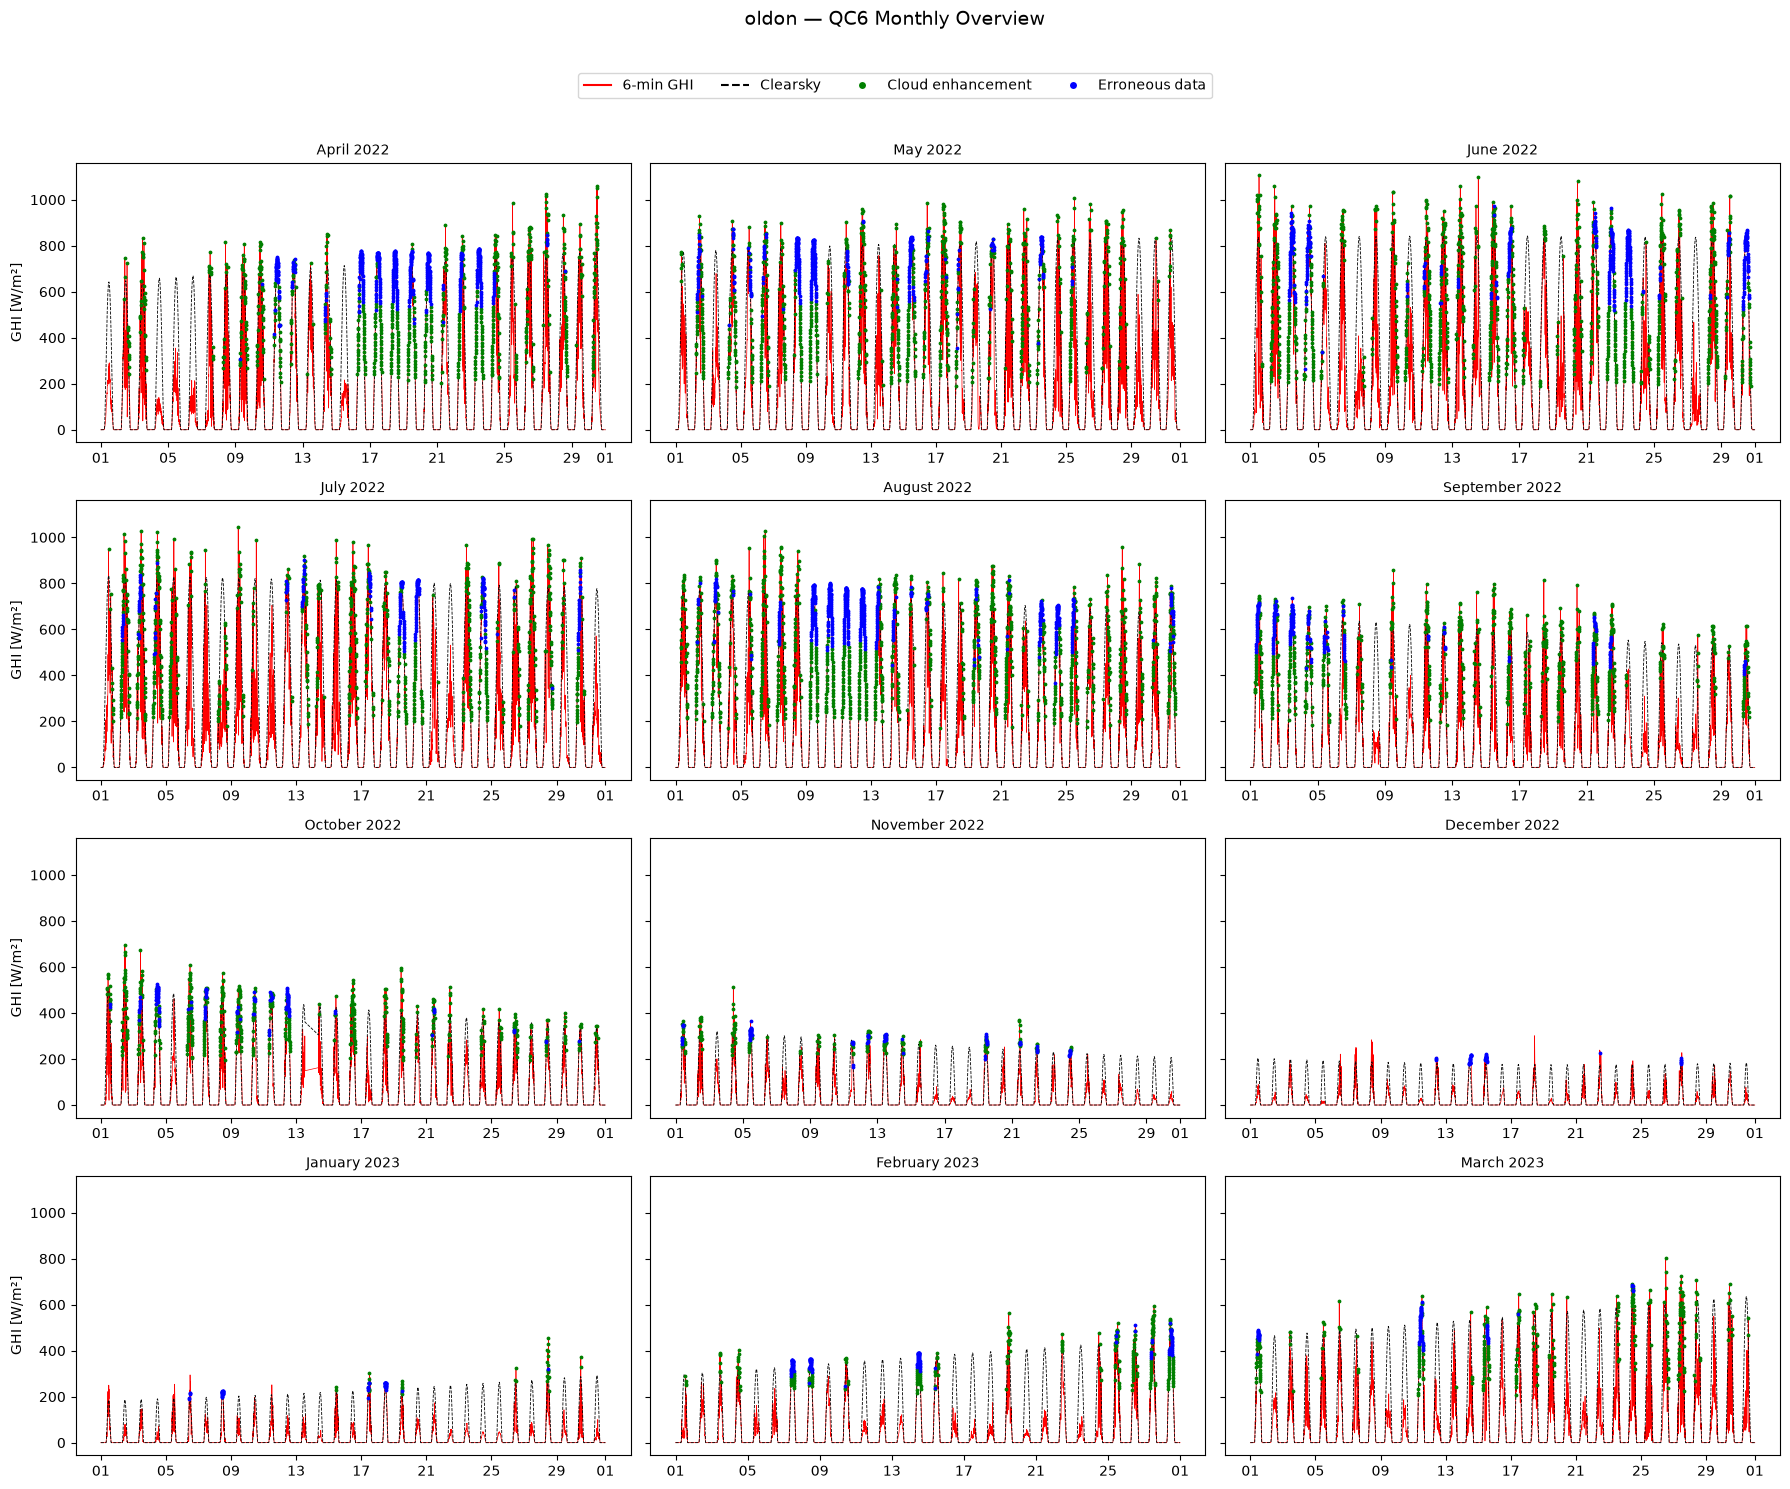

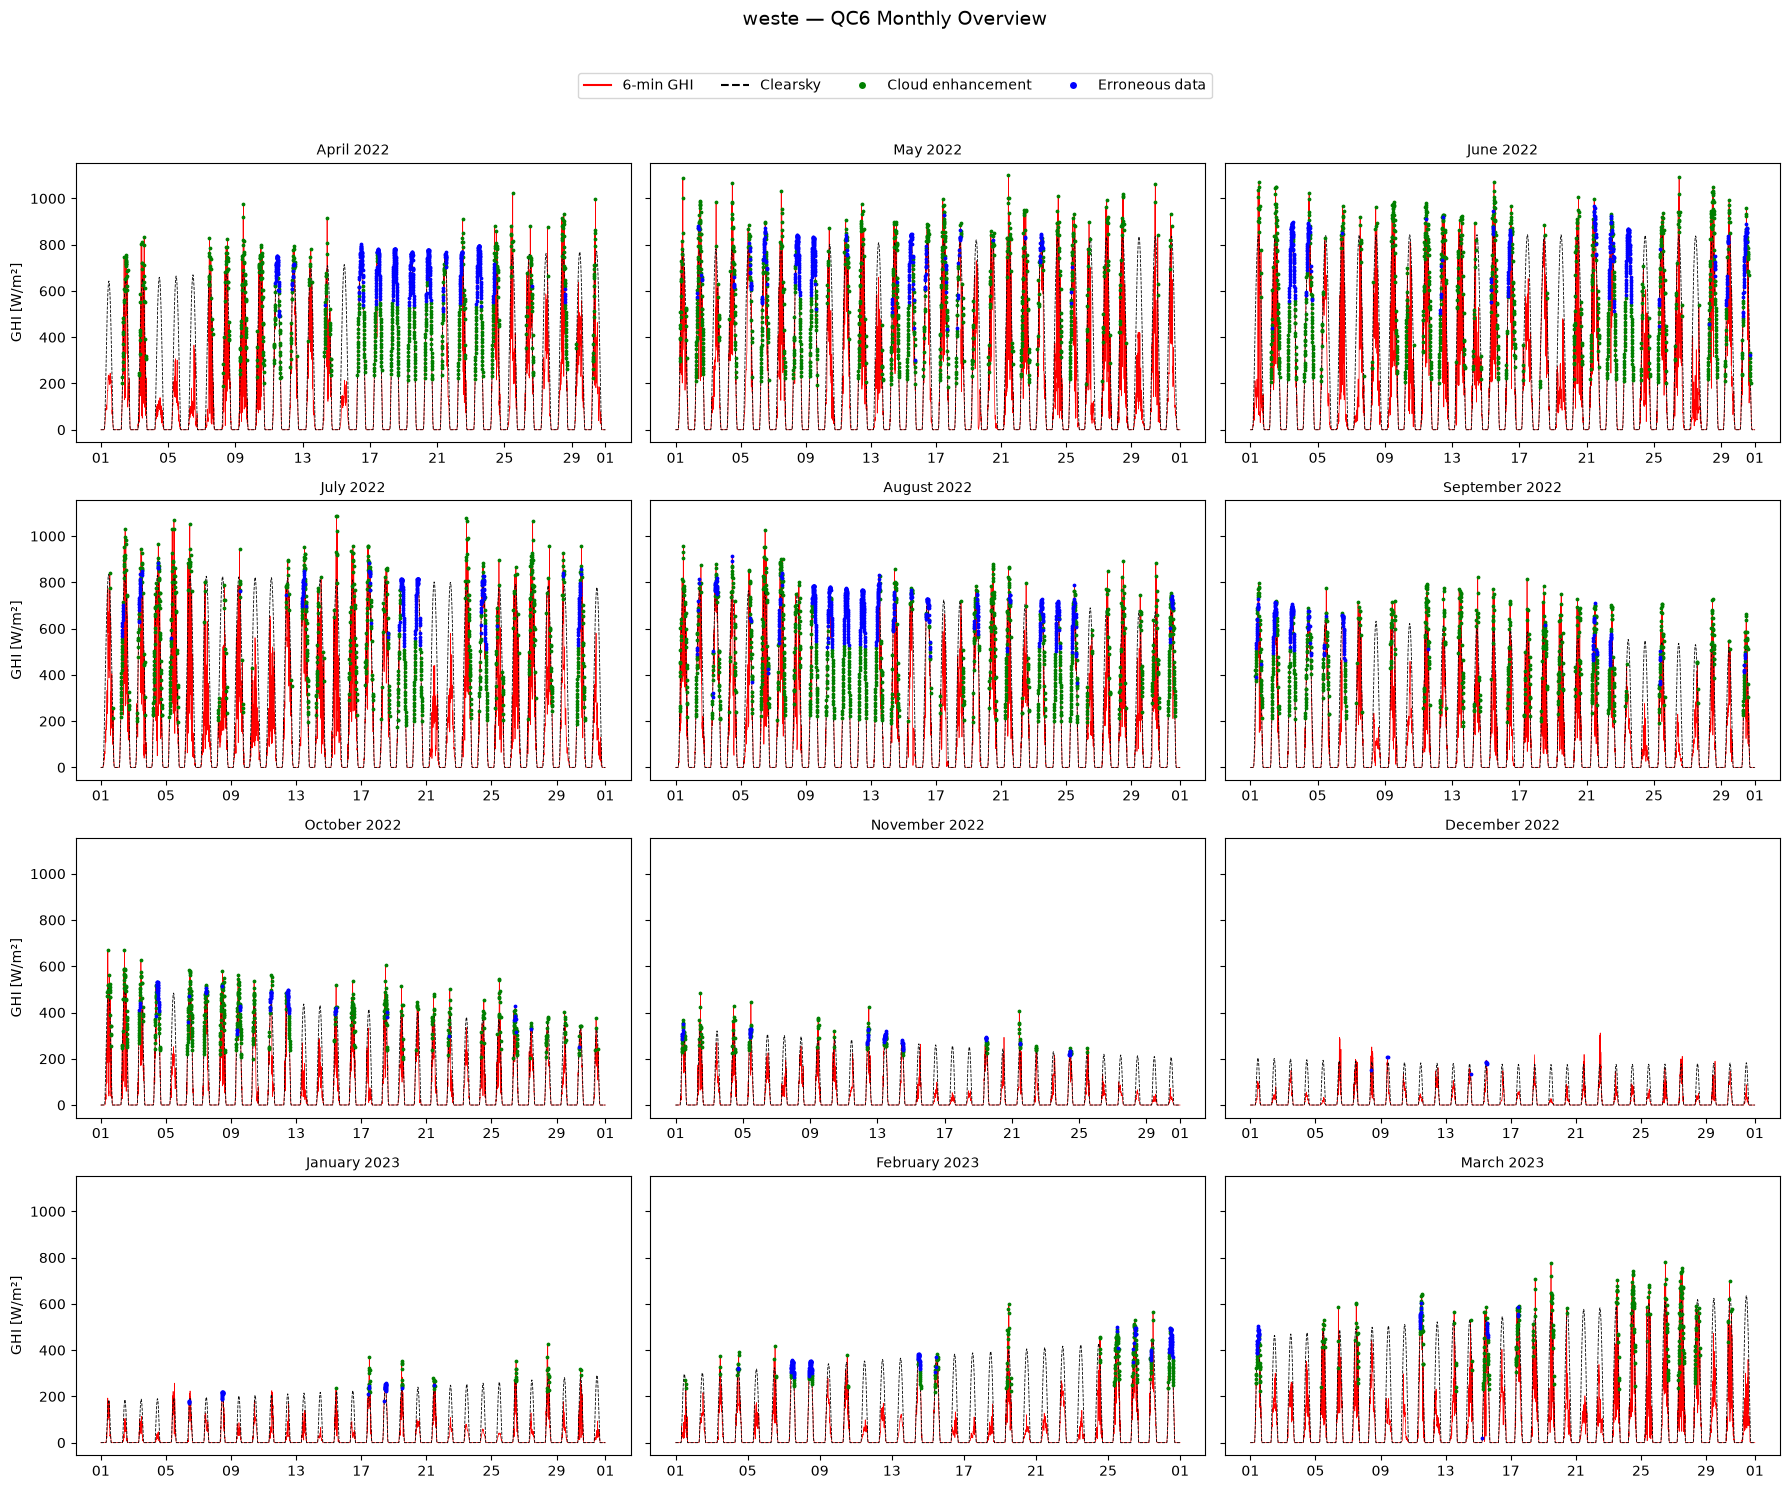

In [117]:
def qc6_cloud_enhancement(ghi, clearsky_ghi, sza, agg_minutes=6, source_resolution_minutes=1):
    """
    QC6 — Cloud enhancement / erroneous data detection (BSRN six-step QC, IEEE 2018).
    """
    df = pd.DataFrame({'GHI': ghi, 'Clearsky': clearsky_ghi, 'SZA': sza})

    # Aggregate to 6-min
    df_agg = df.resample(f'{agg_minutes}min').mean()
    valid_counts = df['GHI'].notna().astype(int).resample(f'{agg_minutes}min').sum()
    min_required = max(1, agg_minutes // source_resolution_minutes // 2)
    df_agg = df_agg[valid_counts >= min_required]

    # window size scales with source resolution
    n_points = agg_minutes // source_resolution_minutes
    rolling_std = df_agg['GHI'].rolling(window=n_points, center=True).std()

    # check if it exceeds clearsky?
    exceeds_clearsky = df_agg['GHI'] > df_agg['Clearsky']

    # split into cloud enhancement vs erroneous
    std_threshold = 0.05 * df_agg['Clearsky']
    cloud_enhancement = exceeds_clearsky & (rolling_std > std_threshold) & (df_agg['SZA'] < 75)
    erroneous = exceeds_clearsky & (rolling_std <= std_threshold)
    
    df_agg.index = df_agg.index.tz_localize(None)
    cloud_enhancement.index = cloud_enhancement.index.tz_localize(None)
    erroneous.index = erroneous.index.tz_localize(None)

    return df_agg, cloud_enhancement, erroneous

#Get the stations 
def prepare_station(df, lat, lon):
    location = pvlib.location.Location(latitude=lat, longitude=lon)
    solpos = location.get_solarposition(df.index)
    clearsky = location.get_clearsky(df.index, model='ineichen')
    df_agg, cloud_enhancement, erroneous = qc6_cloud_enhancement(
        ghi=df['GHI'], clearsky_ghi=clearsky['ghi'], sza=solpos['zenith']
    )
    return df_agg, cloud_enhancement, erroneous

df_agg_oldon, ce_oldon, err_oldon = prepare_station(df_oldon, lat=53.14637, lon=8.21733)
df_agg_weste, ce_weste, err_weste = prepare_station(df_weste, lat=53.25335, lon=7.92658)

print(f"oldon — cloud enhancement: {ce_oldon.sum()} ({ce_oldon.mean()*100:.2f}%) | erroneous: {err_oldon.sum()} ({err_oldon.mean()*100:.2f}%)")
print(f"weste — cloud enhancement: {ce_weste.sum()} ({ce_weste.mean()*100:.2f}%) | erroneous: {err_weste.sum()} ({err_weste.mean()*100:.2f}%)")


# Monthly plot function 

def plot_monthly_qc6_grid(df_agg, cloud_enhancement, erroneous, station_name, n_cols=3):
    months = pd.period_range(df_agg.index.min(), df_agg.index.max(), freq='M')
    n_rows = -(-len(months) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 3.5*n_rows), sharey=True)
    axes = axes.flatten()

    for i, month in enumerate(months):
        ax = axes[i]
        mask = (df_agg.index >= month.start_time) & (df_agg.index <= month.end_time)

        ax.plot(df_agg.index[mask], df_agg['GHI'][mask], color='red', linewidth=0.5)
        ax.plot(df_agg.index[mask], df_agg['Clearsky'][mask], color='black', linestyle='--', linewidth=0.6)

        ce_mask = mask & cloud_enhancement
        err_mask = mask & erroneous
        ax.scatter(df_agg.index[ce_mask], df_agg['GHI'][ce_mask], color='green', s=3, zorder=3)
        ax.scatter(df_agg.index[err_mask], df_agg['GHI'][err_mask], color='blue', s=3, zorder=3)

        ax.set_title(month.strftime('%B %Y'), fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
        ax.set_ylabel('GHI [W/m²]' if i % n_cols == 0 else '')

    for j in range(len(months), len(axes)):
        axes[j].axis('off')

    legend_elements = [
        Line2D([0], [0], color='red', lw=1.5, label='6-min GHI'),
        Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Clearsky'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=6, label='Cloud enhancement'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='Erroneous data'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02), fontsize=10)

    fig.suptitle(f'{station_name} — QC6 Monthly Overview', fontsize=14, y=1.06)
    plt.tight_layout()
    plt.show()



plot_monthly_qc6_grid(df_agg_oldon, ce_oldon, err_oldon, 'oldon')
plot_monthly_qc6_grid(df_agg_weste, ce_weste, err_weste, 'weste')

In [118]:
def monthly_ce_stats(df_agg, cloud_enhancement, erroneous, station_name):
    df = df_agg.copy()
    df['cloud_enhancement'] = cloud_enhancement
    df['erroneous'] = erroneous
    df['month'] = df.index.to_period('M')

    monthly = df.groupby('month').agg(
        total_points        = ('GHI', 'count'),
        ce_count            = ('cloud_enhancement', 'sum'),
        err_count           = ('erroneous', 'sum'),
        mean_GHI            = ('GHI', 'mean'),
        max_GHI             = ('GHI', 'max'),
        mean_clearsky       = ('Clearsky', 'mean'),
    ).reset_index()

    monthly['ce_pct']  = monthly['ce_count']  / monthly['total_points'] * 100
    monthly['err_pct'] = monthly['err_count'] / monthly['total_points'] * 100
    monthly.insert(0, 'station', station_name)

    return monthly

stats_oldon = monthly_ce_stats(df_agg_oldon, ce_oldon, err_oldon, 'oldon')
stats_weste = monthly_ce_stats(df_agg_weste, ce_weste, err_weste, 'weste')

# Combined table
stats_all = pd.concat([stats_oldon, stats_weste])
print(stats_all.to_string(index=False))

station   month  total_points  ce_count  err_count   mean_GHI     max_GHI  mean_clearsky    ce_pct  err_pct
  oldon 2022-04          7200       768        497 180.616021 1059.216667     236.755512 10.666667 6.902778
  oldon 2022-05          7440       856        360 218.309805 1007.666667     298.460158 11.505376 4.838710
  oldon 2022-06          7200      1075        448 244.710847 1105.366667     323.619923 14.930556 6.222222
  oldon 2022-07          7440       820        259 211.196466 1043.750000     303.162604 11.021505 3.481183
  oldon 2022-08          7440      1173        545 214.680334 1029.250000     248.207204 15.766129 7.325269
  oldon 2022-09          7200       715        225 132.346306  860.066667     177.946621  9.930556 3.125000
  oldon 2022-10          7237       556        137  84.211221  697.583333     107.697714  7.682741 1.893050
  oldon 2022-11          7200       171         95  35.072169  512.166667      54.215305  2.375000 1.319444
  oldon 2022-12          744

**K-Tests**

the NREL K-value test provides another 2-component QC method by operating in a dimensionless space where solar irradiance is normalised against extraterrestrial values. https://doi.org/10.1016/j.egypro.2015.03.205 

Defining fixed upper limits for GHI and DHI can be highly challenging at a local site due to atmospheric instabilities like cloud enhancement, smoke, or aerosols. These conditions can cause diffuse radiation to spike unpredictably, momentarily driving GHI beyond standard clear-sky or top-of-atmosphere limits. To account for this, the K-value test utilizes transmittance calculations, specifically checking diffuse horizontal transmittance and beam transmittance as a function of the global horizontal transmittance (also known as the clearness index).

=== oldon ===
  KT-Kn flags: 0
  KT-Kd flags: 69
  Total K    : 69

=== weste ===
  KT-Kn flags: 1
  KT-Kd flags: 118
  Total K    : 119


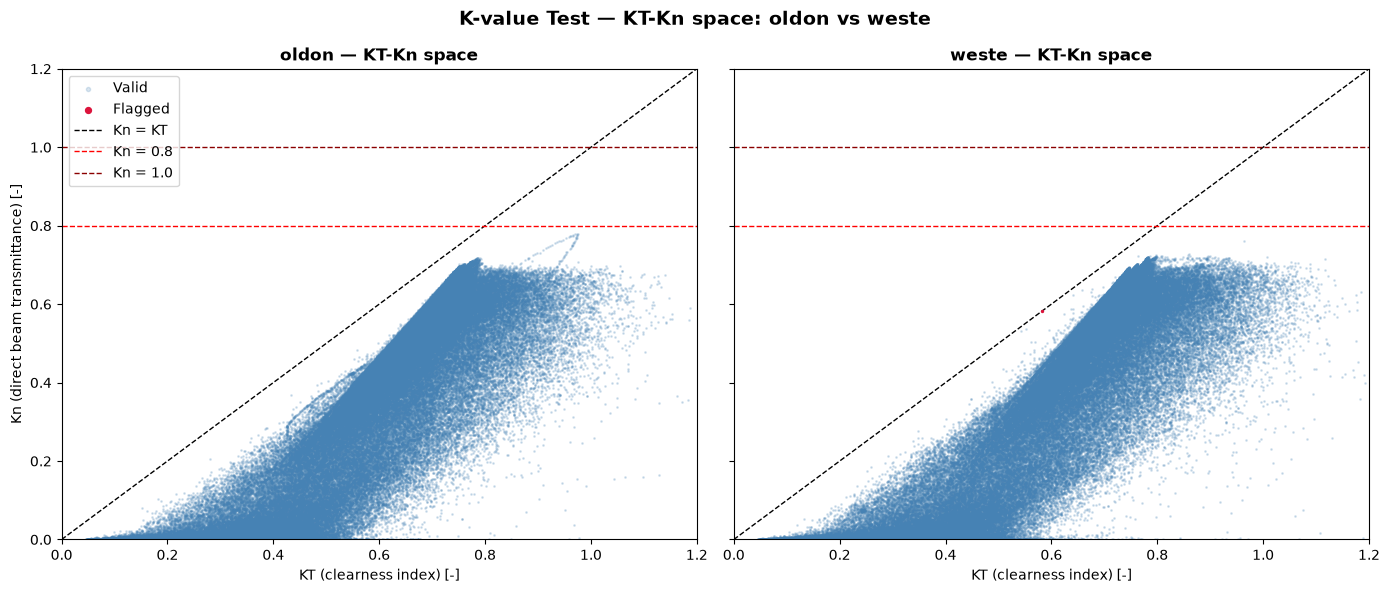

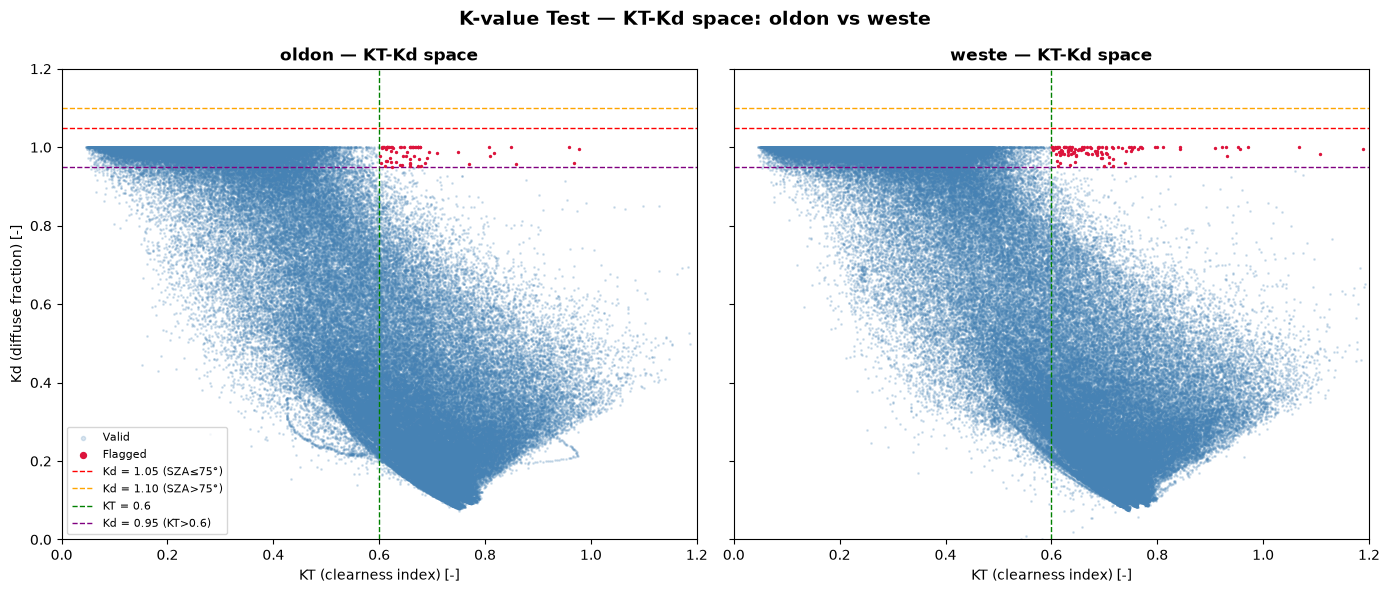

In [119]:
def test_k_values(ghi, dhi, dni, solpos, times):
    sza      = solpos['apparent_zenith'].values
    dni_extra = pvlib.irradiance.get_extra_radiation(times).values
    cos_sza  = np.cos(np.radians(sza))

    # compute indices
    with np.errstate(divide='ignore', invalid='ignore'):
        kn = np.where(dni_extra > 0, dni / dni_extra, np.nan)
        kd = np.where(ghi > 50,     dhi / ghi, np.nan)
        kt = np.where(dni_extra * cos_sza > 10,
                      ghi / (dni_extra * cos_sza), np.nan)

    # valid domain
    valid = (ghi > 50) & (sza < 93) & ~np.isnan(kn) & ~np.isnan(kd) & ~np.isnan(kt)

    # Test 1 — KT-Kn space
    flag_kn = (
        (kn > kt)  |   # direct beam exceeds global — impossible
        (kn > 0.8) |   # extremely rare
        (kn > 1.0)     # physically impossible
    ) & valid

    # Test 2 — KT-Kd space
    flag_kd = (
        ((sza <= 75) & (kd > 1.05)) |
        ((sza >  75) & (kd > 1.10)) |
        ((kt > 0.6)  & (kd > 0.95))   # clear sky — diffuse fraction too high
    ) & valid

    # combined
    flag_k = flag_kn | flag_kd
    flag_k[np.isnan(ghi) | np.isnan(dhi) | np.isnan(dni)] = False

    return kn, kd, kt, flag_kn, flag_kd, flag_k, valid

# run for both stations
kn_olw, kd_olw, kt_olw, flag_kn_olw, flag_kd_olw, flag_k_olw, valid_olw = test_k_values(ghi_oldon, dhi_oldon, dni_oldon, solpos_oldon, times_oldon)
kn_esr, kd_esr, kt_esr, flag_kn_esr, flag_kd_esr, flag_k_esr, valid_esr = test_k_values(ghi_weste, dhi_weste, dni_weste, solpos_weste, times_weste)

print("=== oldon ===")
print("  KT-Kn flags:", flag_kn_olw.sum())
print("  KT-Kd flags:", flag_kd_olw.sum())
print("  Total K    :", flag_k_olw.sum())

print("\n=== weste ===")
print("  KT-Kn flags:", flag_kn_esr.sum())
print("  KT-Kd flags:", flag_kd_esr.sum())
print("  Total K    :", flag_k_esr.sum())

# --- PLOT 1: KT-Kn space ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (name, kt, kn, flag_kn, valid) in zip(axes, [
    ('oldon', kt_olw, kn_olw, flag_kn_olw, valid_olw),
    ('weste', kt_esr, kn_esr, flag_kn_esr, valid_esr)
]):
    ax.scatter(kt[valid & ~flag_kn], kn[valid & ~flag_kn],
               s=1, alpha=0.2, color='steelblue', label='Valid')
    ax.scatter(kt[valid & flag_kn], kn[valid & flag_kn],
               s=8, color='crimson', marker='.', zorder=5, label='Flagged')

    # limit lines
    kt_range = np.linspace(0, 1.2, 500)
    ax.plot(kt_range, kt_range, 'k--', lw=1, label='Kn = KT')
    ax.axhline(0.8, color='red', lw=1, linestyle='--', label='Kn = 0.8')
    ax.axhline(1.0, color='darkred', lw=1, linestyle='--', label='Kn = 1.0')

    ax.set_title(f'{name} — KT-Kn space', fontsize=12, fontweight='bold')
    ax.set_xlabel('KT (clearness index) [-]')
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)

axes[0].set_ylabel('Kn (direct beam transmittance) [-]')
axes[0].legend(loc='upper left', markerscale=3)
fig.suptitle('K-value Test — KT-Kn space: oldon vs weste',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- PLOT 2: KT-Kd space ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (name, kt, kd, flag_kd, valid) in zip(axes, [
    ('oldon', kt_olw, kd_olw, flag_kd_olw, valid_olw),
    ('weste', kt_esr, kd_esr, flag_kd_esr, valid_esr)
]):
    ax.scatter(kt[valid & ~flag_kd], kd[valid & ~flag_kd],
               s=1, alpha=0.2, color='steelblue', label='Valid')
    ax.scatter(kt[valid & flag_kd], kd[valid & flag_kd],
               s=8, color='crimson', marker='.', zorder=5, label='Flagged')

    # limit lines
    ax.axhline(1.05, color='red',    lw=1, linestyle='--', label='Kd = 1.05 (SZA≤75°)')
    ax.axhline(1.10, color='orange', lw=1, linestyle='--', label='Kd = 1.10 (SZA>75°)')
    ax.axvline(0.6,  color='green',  lw=1, linestyle='--', label='KT = 0.6')
    ax.axhline(0.95, color='purple', lw=1, linestyle='--', label='Kd = 0.95 (KT>0.6)')

    ax.set_title(f'{name} — KT-Kd space', fontsize=12, fontweight='bold')
    ax.set_xlabel('KT (clearness index) [-]')
    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)

axes[0].set_ylabel('Kd (diffuse fraction) [-]')
axes[0].legend(loc='lower left', markerscale=3, fontsize=8)
fig.suptitle('K-value Test — KT-Kd space: oldon vs weste',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [120]:
#combine all flags into one boolean array per station
ppl_olw = flags_oldon[['GHI_exceeds_PPL','DHI_exceeds_PPL','DNI_exceeds_PPL']].any(axis=1).values
erl_olw = flags_oldon[['GHI_exceeds_ERL','DHI_exceeds_ERL','DNI_exceeds_ERL']].any(axis=1).values
ppl_esr = flags_weste[['GHI_exceeds_PPL','DHI_exceeds_PPL','DNI_exceeds_PPL']].any(axis=1).values
erl_esr = flags_weste[['GHI_exceeds_ERL','DHI_exceeds_ERL','DNI_exceeds_ERL']].any(axis=1).values

total_flag_oldon = ppl_olw | erl_olw | flags_olw | flag_2c_oldon | flag_kn_olw | flag_kd_olw
total_flag_weste = ppl_esr | erl_esr | flags_esr | flag_2c_weste | flag_kn_esr | flag_kd_esr

print('--- oldon ---')
print(f'PPL: {ppl_olw.sum()}')
print(f'ERL: {erl_olw.sum()}')
print(f'Closure: {flags_olw.sum()}')
print(f'Two-component: {flag_2c_oldon.sum()}')
print(f'K-value (Kn) : {flag_kn_olw.sum()}')
print(f'K-value (Kd) : {flag_kd_olw.sum()}')
print(f'  --- ')
print(f'Sum of tests : {ppl_olw.sum() + erl_olw.sum() + flags_olw.sum() + flag_2c_oldon.sum() + flag_kn_olw.sum() + flag_kd_olw.sum()} (includes double-counts)')
print(f'TOTAL unique : {total_flag_oldon.sum()} / {len(total_flag_oldon)} ({100*total_flag_oldon.mean():.2f}%)')

print('\n--- weste ---')
print(f'PPL: {ppl_esr.sum()}')
print(f'ERL: {erl_esr.sum()}')
print(f'Closure: {flags_esr.sum()}')
print(f'Two-component: {flag_2c_weste.sum()}')
print(f'K-value (Kn) : {flag_kn_esr.sum()}')
print(f'K-value (Kd) : {flag_kd_esr.sum()}')
print(f' --- ')
print(f'Sum of tests : {ppl_esr.sum() + erl_esr.sum() + flags_esr.sum() + flag_2c_weste.sum() + flag_kn_esr.sum() + flag_kd_esr.sum()} (includes double-counts)')
print(f'TOTAL unique : {total_flag_weste.sum()} / {len(total_flag_weste)} ({100*total_flag_weste.mean():.2f}%)')

--- oldon ---
PPL: 5
ERL: 163
Closure: 0
Two-component: 0
K-value (Kn) : 0
K-value (Kd) : 69
  --- 
Sum of tests : 237 (includes double-counts)
TOTAL unique : 222 / 525600 (0.04%)

--- weste ---
PPL: 2
ERL: 150
Closure: 0
Two-component: 0
K-value (Kn) : 1
K-value (Kd) : 118
 --- 
Sum of tests : 271 (includes double-counts)
TOTAL unique : 230 / 525600 (0.04%)


In [121]:
#add
flags_oldon['Closure']         = flags_olw
flags_oldon['Two-component']   = flag_2c_oldon
flags_oldon['K-value Kn']      = flag_kn_olw
flags_oldon['K-value Kd']      = flag_kd_olw

flags_weste['Closure']       = flags_esr
flags_weste['Two-component'] = flag_2c_weste
flags_weste['K-value Kn']    = flag_kn_esr
flags_weste['K-value Kd']    = flag_kd_esr

In [122]:
# organize QC flags by irradiance component so that each variable is
# evaluated only with the tests applicable to its physical definition.
flags_by_comp_oldon = {
    'GHI': {
        'ERL': flags_oldon['GHI_exceeds_ERL'].values, 'Closure': flags_oldon['Closure'], 'Two-component': flags_oldon['Two-component'],
        'K-value Kn': flags_oldon['K-value Kn'], 'K-value Kd': flag_kd_olw, 'GHI_exceeds_PPL': flags_oldon['GHI_exceeds_PPL'].values,
        #'Dumortier': result_oldon['flag'].values,
    },
    'DHI': {
        'ERL': flags_oldon['DHI_exceeds_ERL'].values, 'Closure': flags_olw, 'Two-component': flag_2c_oldon,
        'K-value Kd': flag_kd_olw, 'PPL': flags_oldon['DHI_exceeds_PPL'].values,
    },
    'DNI': {
        'ERL': flags_oldon['DNI_exceeds_ERL'].values, 'Closure': flags_olw,
        'K-value Kn': flag_kn_olw, 'PPL': flags_oldon['DNI_exceeds_PPL'].values,
    },
}

flags_by_comp_weste = {
    'GHI': {
        'ERL': flags_weste['GHI_exceeds_ERL'].values, 'Closure': flags_esr, 'Two-component': flag_2c_weste,
        'K-value Kn': flag_kn_esr, 'K-value Kd': flag_kd_esr, 'PPL': flags_weste['GHI_exceeds_PPL'].values,
        #'Dumortier': result_weste['flag'].values,
    },
    'DHI': {
        'ERL': flags_weste['DHI_exceeds_ERL'].values, 'Closure': flags_esr, 'Two-component': flag_2c_weste,
        'K-value Kd': flag_kd_esr, 'PPL': flags_weste['DHI_exceeds_PPL'].values,
    },
    'DNI': {
        'ERL': flags_weste['DNI_exceeds_ERL'].values, 'Closure': flags_esr, 'K-value Kn': flag_kn_esr,
        'PPL': flags_weste['DNI_exceeds_PPL'].values,
    },
}

In [123]:

flag_colors = {
    'GHI_exceeds_PPL': 'darkred', 'DHI_exceeds_ERL': 'black', 'Closure': 'blue', 'Two-component': 'green',
    'K-value Kn': 'purple', 'K-value Kd': 'crimson', 'GHI_exceeds_PPL':'yellow' , 'DHI_exceeds_PPL': 'lightgreen', 'DNI_exceeds_ERL' :'lightblue','DNI_exceeds_PPL' :'darkgreen',#'Dumortier': 'teal',
}

In [124]:
def to_flag_day(flags_df, times):
    flags_df = flags_df.copy()
    flags_df.index = times
    expanded = flags_df.groupby(flags_df.index.date).transform('any')
    expanded.index = times
    return expanded

flags_oldon_daily = to_flag_day(flags_oldon, times_oldon)
flags_weste_daily = to_flag_day(flags_weste, times_weste)

print(flags_oldon_daily.sum())

GHI_exceeds_ERL    20160
GHI_exceeds_PPL        0
DHI_exceeds_ERL    21600
DHI_exceeds_PPL     2880
DNI_exceeds_ERL     1440
DNI_exceeds_PPL        0
Closure                0
Two-component          0
K-value Kn             0
K-value Kd         36000
dtype: int64


In [125]:
#assign the bit position for each test.
bin_flag_pos = {
    'GHI_exceeds_PPL': 1 << 0,
    'GHI_exceeds_ERL': 1 << 1,
    'DHI_exceeds_ERL': 1 << 2,
    'DHI_exceeds_PPL': 1 << 3,
    'DNI_exceeds_ERL': 1 << 4,
    'DNI_exceeds_PPL': 1 << 5,
    'Closure'        : 1 << 6,
    'Two-component'  : 1 << 7,
    'K-value Kn'     : 1 << 8,
    'K-value Kd'     : 1 << 9, 
    #'Dumortier'     : 1 << 10,
}

Flag_Meanings = {v: k for k, v in bin_flag_pos.items()}


def assign_binary_flags(flags_df):

    df = flags_df.copy()
    
    #binary columns
    binary_cols ={}
    for test_name in bin_flag_pos:
        binary_cols[f'{test_name}_bin'] = df[test_name].astype(int).values
    binary_df = pd.DataFrame(binary_cols, index=df.index)
    
    #summing all the tests that were flagged
    bitmask =np.zeros(len(df), dtype =np.int64)
    for test_name, bit in bin_flag_pos.items():
        bitmask += df[test_name].astype(int).values * bit
    
    binary_df['QC_bitmask'] = bitmask
    binary_df['suspect'] = bitmask > 0
    
    return binary_df



def decode_bitmask(bitmask_value):
    return [name for bit, name in bin_flag_pos.items() if bitmask_value & bit]


#run
binary_oldon = assign_binary_flags(flags_oldon_daily)
binary_weste = assign_binary_flags(flags_weste_daily)


In [126]:
for station, binary_df in [('oldon', binary_oldon), ('weste', binary_weste)]:
    print(f'\n=== {station} ===')
    for test_name in bin_flag_pos:
        col = f'{test_name}_bin'
        count = binary_df[col].sum()
        pct = binary_df[col].mean() * 100
        print(f'  {test_name:20s}: {count:>7,} ({pct:.2f}%)')
    print(f'  {"TOTAL suspect":20s}: {binary_df["suspect"].sum():>7,} ({binary_df["suspect"].mean()*100:.2f}%)')


=== oldon ===
  GHI_exceeds_PPL     :       0 (0.00%)
  GHI_exceeds_ERL     :  20,160 (3.84%)
  DHI_exceeds_ERL     :  21,600 (4.11%)
  DHI_exceeds_PPL     :   2,880 (0.55%)
  DNI_exceeds_ERL     :   1,440 (0.27%)
  DNI_exceeds_PPL     :       0 (0.00%)
  Closure             :       0 (0.00%)
  Two-component       :       0 (0.00%)
  K-value Kn          :       0 (0.00%)
  K-value Kd          :  36,000 (6.85%)
  TOTAL suspect       :  57,600 (10.96%)

=== weste ===
  GHI_exceeds_PPL     :       0 (0.00%)
  GHI_exceeds_ERL     :  36,000 (6.85%)
  DHI_exceeds_ERL     :  34,560 (6.58%)
  DHI_exceeds_PPL     :   2,880 (0.55%)
  DNI_exceeds_ERL     :       0 (0.00%)
  DNI_exceeds_PPL     :       0 (0.00%)
  Closure             :       0 (0.00%)
  Two-component       :       0 (0.00%)
  K-value Kn          :   1,440 (0.27%)
  K-value Kd          :  38,880 (7.40%)
  TOTAL suspect       :  67,680 (12.88%)


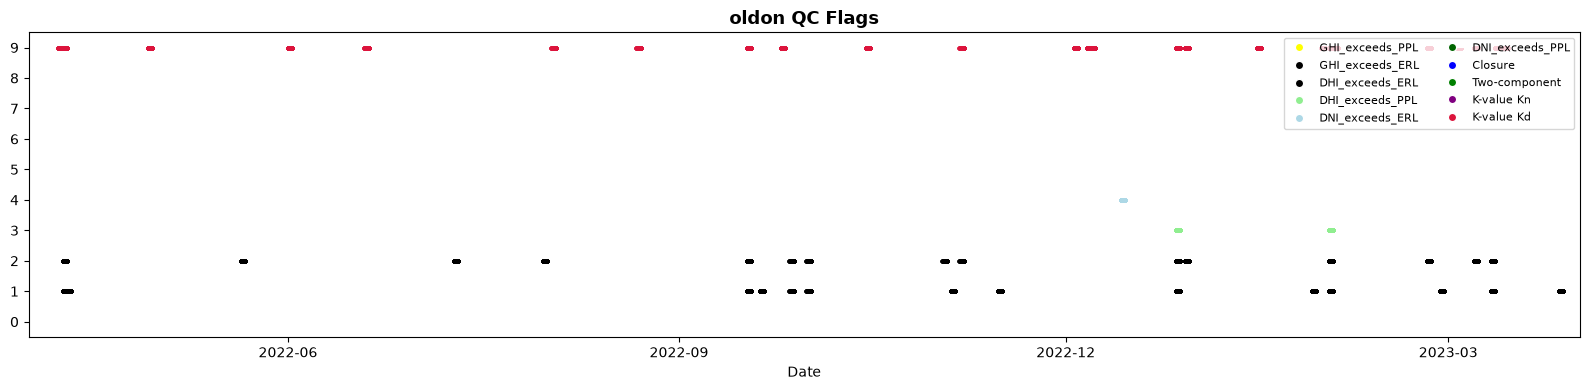

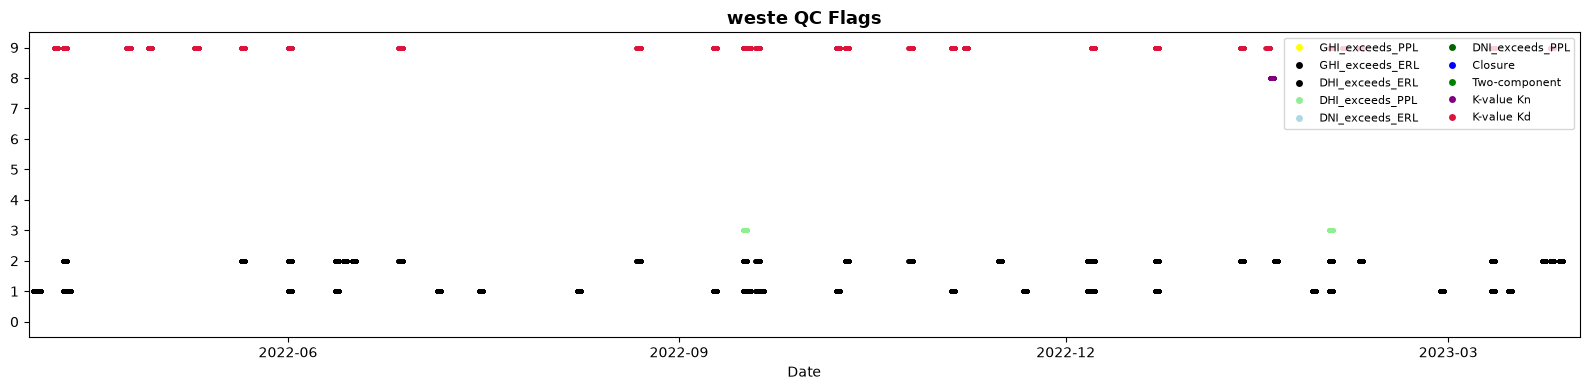

In [127]:
def plot_binary_flags_combined(binary_df, times, station_name, flag_colors):

    test_names = [t for t in bin_flag_pos.keys() if f'{t}_bin' in binary_df.columns]
    n = len(test_names)

    fig, ax = plt.subplots(figsize=(16, 4))

    for i, test_name in enumerate(test_names):
        col = f'{test_name}_bin'
        flag = binary_df[col].values.astype(bool)
        color = flag_colors.get(test_name, 'black')


        ax.scatter(times[flag], np.full(flag.sum(), i),
                color=color, s=4, alpha=0.7, label=test_name)

    ax.set_yticks(range(n))
    #ax.set_yticklabels(test_names, fontsize=9)
    ax.set_xlim(times[0], times[-1])
    ax.set_ylim(-0.5, n - 0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.set_xlabel('Date')
    ax.set_title(f'{station_name} QC Flags',
                fontsize=13, fontweight='bold')

    # legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor=flag_colors.get(t, 'black'),
            markersize=6, label=t)
        for t in test_names
    ]
    ax.legend(handles=legend_elements, loc='upper right',
            fontsize=8, ncol=2, framealpha=0.8)

    plt.tight_layout()
    plt.show()


plot_binary_flags_combined(binary_oldon, times_oldon, 'oldon', flag_colors)
plot_binary_flags_combined(binary_weste, times_weste, 'weste', flag_colors)

### **References**
 
[1] Leen Abdin, Study and develop automated quality control checks for measured data in the 
Energy, Report of Practice Module Engineering Physics, EnergyMeteorology group, University 
of Oldenburg, 2019

[2] Long, C. N. & Shi, Y., An automated quality assessment and control algorithm for surface 
radiation measurements, The Open Atmospheric Science Journal, 2008

[3] Forstinger, A., Wilbert, S., Jensen, A. R., Kraas, B., Peruchena, C. F., Gueymard, C. A., Ronzio, D., Yang, D.,
Collino, E., Martinez, J. P., Ruiz-Arias, J. A., Hanrieder, N., Blanc, P., & Saint-Drenan, Y. M. (2021). Expert
quality control of solar radiation ground data sets. In Proceedings of SWC 2021: ISES Solar World Congress
(pp. 1037-1048). International Solar Energy Society. https://doi.org/10.18086/swc.2021.38.02

[4] https://www.kippzonen.com/hs-fs/hubfs/zero_a.jpeg?width=662&height=431&name=zero_a.jpeg

[5] Aron Habte, Christian Gueymard, Stefan Wilbert, Elke Lorenz, Balenzategui Manzanares, et al.. Principles
and Practical Methods for Estimating Uncertainty and Evaluating Solar Irradiance Data. National Renewable
Energy Laboratory. Best Practices Handbook for the Collection and Use of Solar Resource Data for Solar
Energy Applications: Fourth Edition, https://iea-pvps.org/, 2024, ⟨10.2172/2448063⟩. ⟨hal-04840548
